# Business Intelligence Chatbot Interaction Dataset

# Key Insights

This dataset provides a fascinating look into the interactions with a Business Intelligence (BI) Chatbot, offering a rich source of information to understand how users engage with automated analytical tools. It captures various aspects, from the basic details of each interaction to the chatbot's performance metrics and the user's ultimate feedback.

At a glance, the dataset contains over 3,200 interactions, each with a unique ID and timestamp. The interactions are categorized by department, user_role, the user_query itself, query_category, metrics_requested, and analysis_type. Crucially, it also includes the bot's self-assessed bot_response_confidence and the response_time_ms.

Initial Exploration and Data Quality:

Our initial data exploration revealed a clean dataset, with no duplicate entries. We identified a few missing values in user_feedback_rating and estimated_business_impact, which were subsequently dropped as per the instructions in the notebook.

Key Statistical Insights:

Bot Performance: The bot_response_confidence hovers around a mean of 0.79, indicating a generally high confidence in its responses. The response_time_ms averages about 1.3 seconds, suggesting a reasonably responsive system.
User Behavior: 'What is customer churn rate?' was the most frequent user query, highlighting a strong interest in customer analytics. 'Finance' and 'Revenue' were the most common query categories, suggesting these are critical areas for users. Interactions are spread across departments and user roles relatively evenly.
Temporal Patterns: By extracting hour_of_day, day_of_week, and month from the timestamp, we started to uncover temporal trends. Notably, there was a statistically significant association between day_of_week and month, implying that interaction patterns might shift throughout the year.
Feature Engineering and Model Performance Challenges:

To deepen our understanding and build predictive models, we engineered several new features:

Interaction Counts: Features like department_interaction_count and user_role_interaction_count were created to quantify activity levels.
Query Complexity: query_length and num_query_words provided insights into how verbose user queries were.
Binned Metrics: bot_response_confidence and response_time_ms were binned into categories like 'Low/Medium/High Confidence' and 'Fast/Moderate/Slow Response Time' for easier analysis.
NLP Features: We experimented with advanced text representations, moving from TF-IDF with n-grams to Word2Vec embeddings for the user_query.
Class Imbalance Handling: SMOTE (Synthetic Minority Over-sampling Technique) was applied to address potential class imbalances in our target variables.
Despite these extensive efforts in feature engineering and model optimization, both our Intent Classifier and Response Time Predictor models showed very limited success.

Intent Classifier: Even after trying different algorithms (RandomForest, SVC, XGBoost) and advanced NLP features, the accuracy remained critically low (around 23%). The model struggled particularly with certain categories, such as 'Finance', where it consistently achieved 0% precision, recall, and F1-score. This suggests that the current textual features, even with embeddings, might not be rich enough to capture the nuanced intent behind the queries, or there's insufficient data variability for effective classification.
Response Time Predictor: The performance of this model, measured by R2 score, was negative (-2.9%), indicating it performed worse than simply predicting the average response time. This implies that the features we engineered did not have a strong linear or non-linear relationship with response time, or that other uncaptured factors significantly influence it.
In essence, while the dataset offers valuable descriptive insights into chatbot usage, predicting intent and response time effectively proved challenging with the current feature set and modeling approaches. This points towards the need for more sophisticated techniques, potentially larger and more diverse datasets, or a re-evaluation of the underlying factors influencing these complex chatbot behaviors.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d jawadaahmed/business-intelligence-chatbot-interaction-dataset

# Unziping the downloaded file
!unzip business-intelligence-chatbot-interaction-dataset.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/jawadaahmed/business-intelligence-chatbot-interaction-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
  0% 0.00/71.7k [00:00<?, ?B/s]
100% 71.7k/71.7k [00:00<00:00, 172MB/s]
Archive:  business-intelligence-chatbot-interaction-dataset.zip
  inflating: BI_Chatbot_Interactions.csv  


# Data Inspection

In [ ]:
df = pd.read_csv('BI_Chatbot_Interactions.csv')
df.head(11)

,interaction_id,timestamp,department,user_role,user_query,query_category,metrics_requested,analysis_type,bot_response_confidence,response_time_ms,user_feedback_rating,estimated_business_impact
0,INT-100000,2025-08-12 08:29:31.851880,HR,Intern,Forecast next quarter revenue,Revenue,Revenue,Descriptive,0.73,2381,4.0,High
1,INT-100001,2025-10-08 15:20:31.851905,Operations,Analyst,Forecast next quarter revenue,Marketing,Profit Margin,Descriptive,0.89,635,2.0,Low
2,INT-100002,2025-09-21 01:42:31.851909,Finance,Manager,What is customer churn rate?,Marketing,Conversion Rate,Predictive,0.84,557,5.0,NaN
3,INT-100003,2025-09-07 01:43:31.851912,Operations,Analyst,Compare sales performance by region,Marketing,Conversion Rate,Trend Analysis,0.76,2499,4.0,NaN
4,INT-100004,2025-09-17 20:17:31.851914,Operations,Executive,Which campaign had highest ROI?,Marketing,Conversion Rate,Predictive,0.98,334,2.0,High
5,INT-100005,2025-10-19 16:01:31.851919,Marketing,Executive,Compare sales performance by region,Finance,Conversion Rate,Descriptive,0.89,722,4.0,Medium
6,INT-100006,2025-04-06 03:06:31.851921,Finance,Executive,Compare sales performance by region,Finance,Conversion Rate,Predictive,0.62,1003,4.0,Medium
7,INT-100007,2025-11-16 06:09:31.851925,Finance,Analyst,Which campaign had highest ROI?,Revenue,Profit Margin,Trend Analysis,0.89,279,1.0,Low
8,INT-100008,2025-09-11 12:04:31.851933,Finance,Intern,Forecast next quarter revenue,Sales,Churn Rate,Descriptive,0.61,1676,3.0,NaN
9,INT-100009,2026-01-07 14:22:31.851936,Operations,Analyst,Which campaign had highest ROI?,Sales,ROI,Trend Analysis,0.85,2240,NaN,NaN


In [ ]:
df.tail(11)

,interaction_id,timestamp,department,user_role,user_query,query_category,metrics_requested,analysis_type,bot_response_confidence,response_time_ms,user_feedback_rating,estimated_business_impact
3189,INT-103189,2025-12-18 11:17:31.859623,Marketing,Analyst,Show monthly revenue trend,Marketing,Conversion Rate,Descriptive,0.60,1310,NaN,Low
3190,INT-103190,2025-03-30 14:52:31.859624,Operations,Analyst,Show monthly revenue trend,Revenue,Conversion Rate,Descriptive,0.79,661,2.0,Low
3191,INT-103191,2026-01-30 20:59:31.859626,Finance,Executive,Forecast next quarter revenue,Finance,Conversion Rate,Predictive,0.74,2328,2.0,Low
3192,INT-103192,2025-05-11 17:31:31.859628,Finance,Intern,Which campaign had highest ROI?,Sales,Revenue,Descriptive,0.82,521,4.0,Medium
3193,INT-103193,2025-09-29 03:04:31.859630,Marketing,Manager,Compare sales performance by region,Marketing,Churn Rate,Predictive,0.88,614,1.0,Low
3194,INT-103194,2025-09-02 06:52:31.859632,Marketing,Intern,Forecast next quarter revenue,Marketing,Conversion Rate,Descriptive,0.70,2074,5.0,Medium
3195,INT-103195,2025-03-31 03:53:31.859634,Operations,Intern,Which campaign had highest ROI?,Marketing,ROI,Descriptive,0.66,2437,3.0,High
3196,INT-103196,2025-11-12 01:32:31.859636,HR,Manager,Which campaign had highest ROI?,Customer,ROI,Descriptive,0.71,1456,4.0,Medium
3197,INT-103197,2025-03-29 16:31:31.859638,Marketing,Intern,What is customer churn rate?,Finance,ROI,Trend Analysis,0.60,367,2.0,NaN
3198,INT-103198,2025-03-29 12:00:31.859640,Sales,Manager,What is customer churn rate?,Sales,Profit Margin,Predictive,0.65,1373,4.0,Low


In [ ]:
df.shape

(3200, 12)

In [ ]:
df.columns

Index(['interaction_id', 'timestamp', 'department', 'user_role', 'user_query',
       'query_category', 'metrics_requested', 'analysis_type',
       'bot_response_confidence', 'response_time_ms', 'user_feedback_rating',
       'estimated_business_impact'],
      dtype='object')

In [ ]:
df.dtypes

,0
interaction_id,object
timestamp,object
department,object
user_role,object
user_query,object
query_category,object
metrics_requested,object
analysis_type,object
bot_response_confidence,float64
response_time_ms,int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3200 entries, 0 to 3199
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   interaction_id             3200 non-null   object 
 1   timestamp                  3200 non-null   object 
 2   department                 3200 non-null   object 
 3   user_role                  3200 non-null   object 
 4   user_query                 3200 non-null   object 
 5   query_category             3200 non-null   object 
 6   metrics_requested          3200 non-null   object 
 7   analysis_type              3200 non-null   object 
 8   bot_response_confidence    3200 non-null   float64
 9   response_time_ms           3200 non-null   int64  
 10  user_feedback_rating       2861 non-null   float64
 11  estimated_business_impact  2863 non-null   object 
dtypes: float64(2), int64(1), object(9)
memory usage: 300.1+ KB


In [ ]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
interaction_id,3200,3200,INT-103183,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
timestamp,3200,3200,2025-08-03 04:54:31.859612,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
department,3200,5,HR,660,NaN,NaN,NaN,NaN,NaN,NaN,NaN
user_role,3200,4,Intern,817,NaN,NaN,NaN,NaN,NaN,NaN,NaN
user_query,3200,5,What is customer churn rate?,693,NaN,NaN,NaN,NaN,NaN,NaN,NaN
query_category,3200,5,Finance,671,NaN,NaN,NaN,NaN,NaN,NaN,NaN
metrics_requested,3200,5,Churn Rate,670,NaN,NaN,NaN,NaN,NaN,NaN,NaN
analysis_type,3200,3,Predictive,1093,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bot_response_confidence,3200.0,NaN,NaN,NaN,0.794681,0.111093,0.6,0.7,0.79,0.89,0.99
response_time_ms,3200.0,NaN,NaN,NaN,1363.886563,664.418698,200.0,795.0,1369.5,1941.0,2499.0


In [ ]:
df.isnull().sum()

,0
interaction_id,0
timestamp,0
department,0
user_role,0
user_query,0
query_category,0
metrics_requested,0
analysis_type,0
bot_response_confidence,0
response_time_ms,0


### Dropping missing columns

In [ ]:
df.drop(['user_feedback_rating','estimated_business_impact'], axis = 1, inplace = True)
df.isnull().sum()

,0
interaction_id,0
timestamp,0
department,0
user_role,0
user_query,0
query_category,0
metrics_requested,0
analysis_type,0
bot_response_confidence,0
response_time_ms,0


In [ ]:
df.duplicated().sum()

np.int64(0)

# Multivariate Analysis


Analyzing relationships with Hue: department...


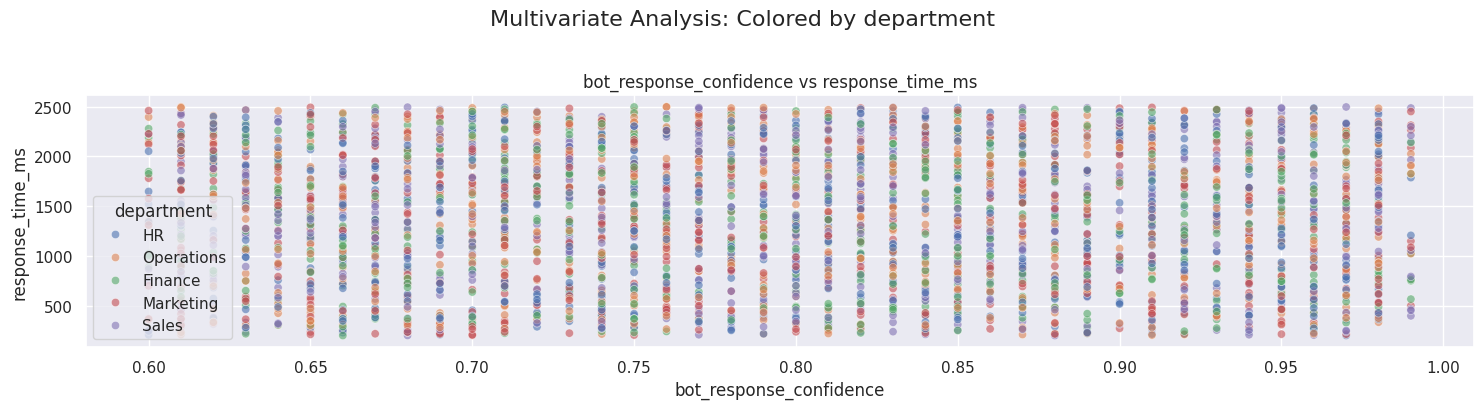


Analyzing relationships with Hue: user_role...


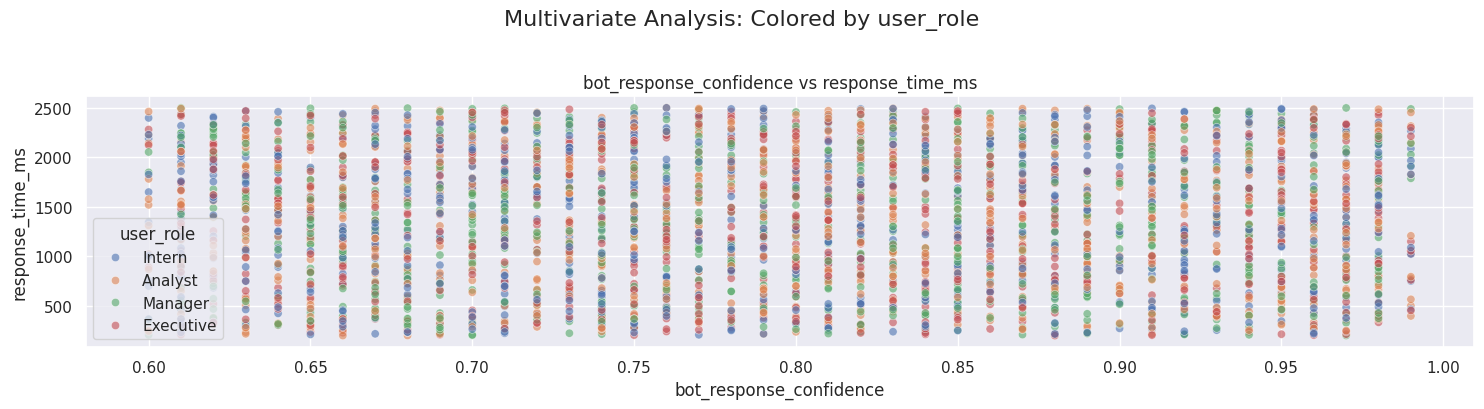


Analyzing relationships with Hue: user_query...


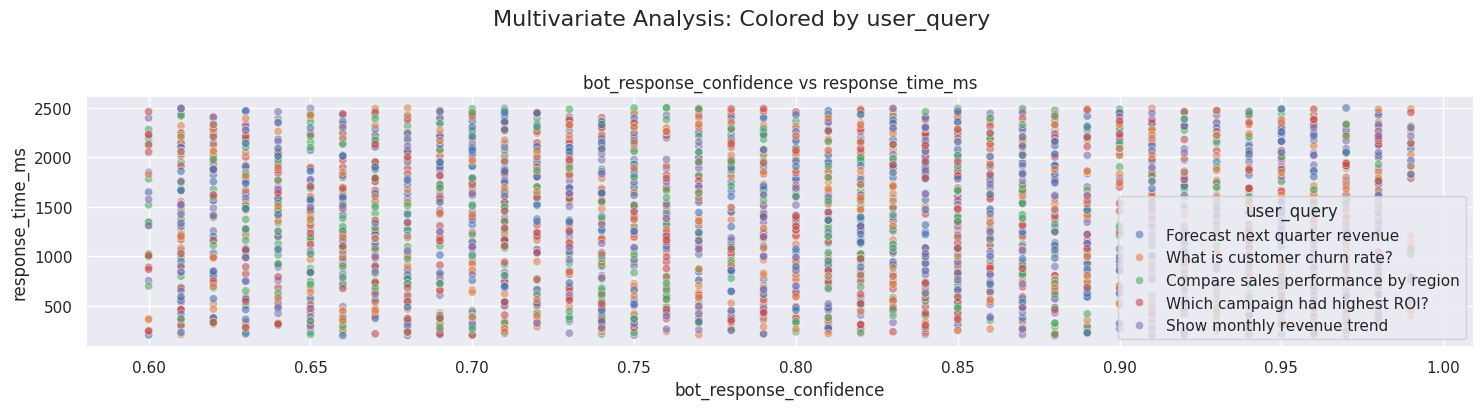


Analyzing relationships with Hue: query_category...


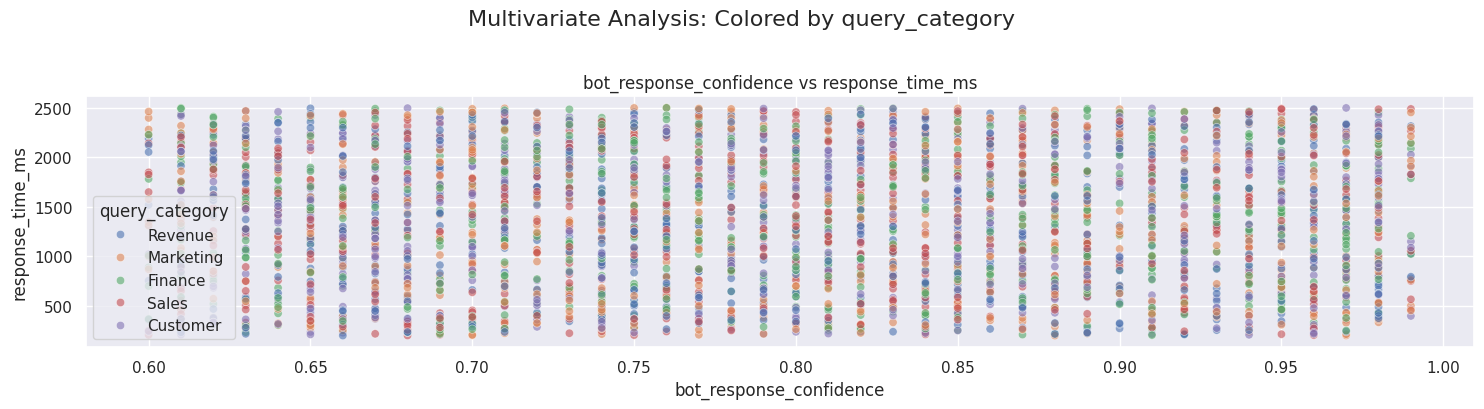


Analyzing relationships with Hue: metrics_requested...


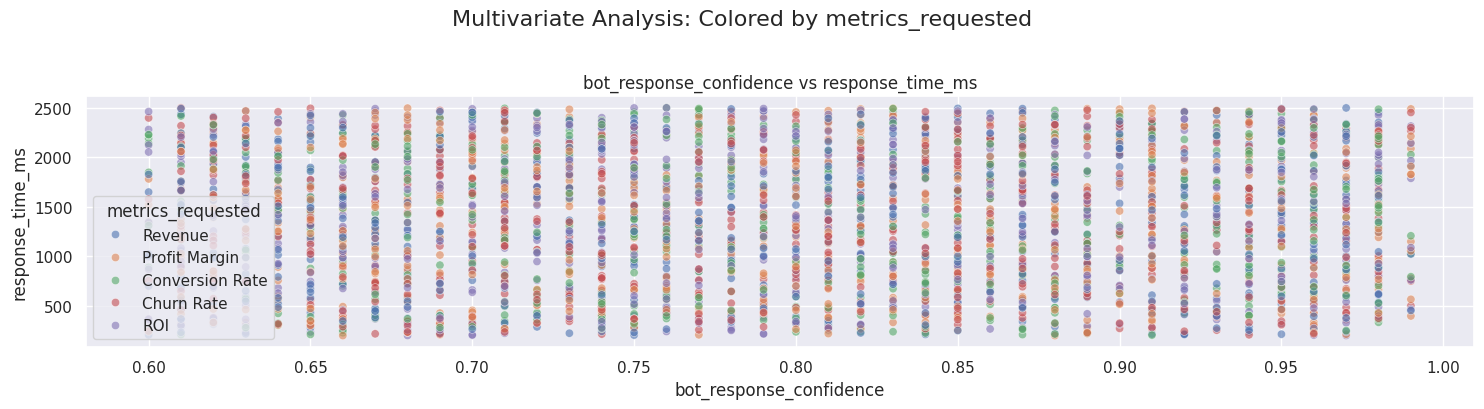


Analyzing relationships with Hue: analysis_type...


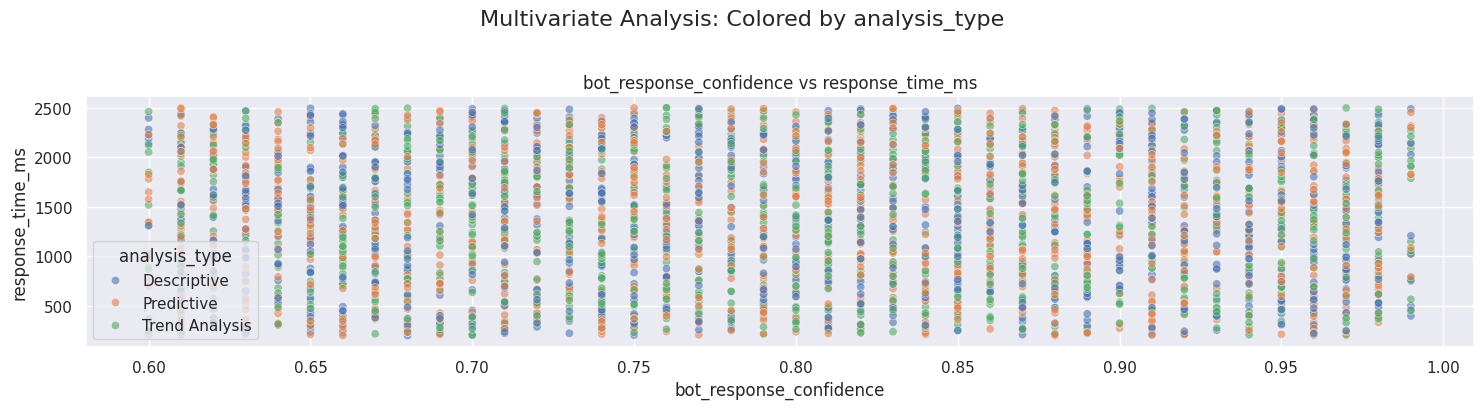

In [ ]:
import itertools
import math

# --- Multivariate Analysis: Numerical Pairs with Categorical Hue ---

# 1. Identifying valid columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
# Filtering categorical columns to those with few unique values for clear legends (e.g., < 10)
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 10]

# Generating pairs of numerical columns to plot
num_pairs = list(itertools.combinations(numerical_cols, 2))

if len(numerical_cols) > 1 and len(categorical_cols) > 0:
    # OUTER LOOP: Iterating through each categorical variable to use as the 'Hue'
    for cat_col in categorical_cols:
        print(f"\nAnalyzing relationships with Hue: {cat_col}...")

        # Defining grid size for the inner loop (numerical pairs)
        num_plots = len(num_pairs)
        if num_plots == 1:
            num_cols_plot = 1
        elif num_plots == 2:
            num_cols_plot = 2
        else:
            num_cols_plot = 3
        num_rows_plot = math.ceil(num_plots / num_cols_plot)

        # Creating figure
        fig, axes = plt.subplots(num_rows_plot, num_cols_plot, figsize=(15, 4 * num_rows_plot))
        # Ensuring axes is always a flat iterable of Axes objects
        if not isinstance(axes, np.ndarray):
            axes = [axes]
        else:
            axes = axes.flatten()

        # INNER LOOP: Iterating through numerical pairs
        for i, (num1, num2) in enumerate(num_pairs):
            if i < num_plots:
                sns.scatterplot(data=df, x=num1, y=num2, hue=cat_col, ax=axes[i], alpha=0.6)
                axes[i].set_title(f'{num1} vs {num2}')
            else:
                axes[i].axis('off')

        # Hiding any remaining unused subplots (this loop might be redundant with the above, but safe)
        for j in range(i + 1, len(axes)):
            axes[j].axis('off')

        plt.suptitle(f'Multivariate Analysis: Colored by {cat_col}', y=1.02, fontsize=16)
        plt.tight_layout()
        plt.show()
        print("="*80)
else:
    print("Not enough data for multivariate scatter analysis (need >1 numerical and >0 categorical columns).")

# Univariate Analysis

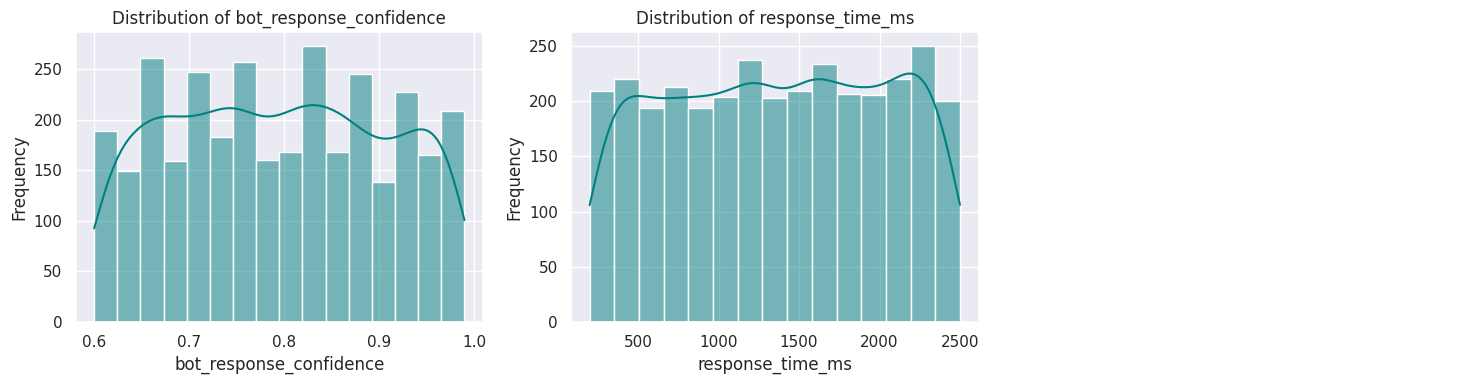

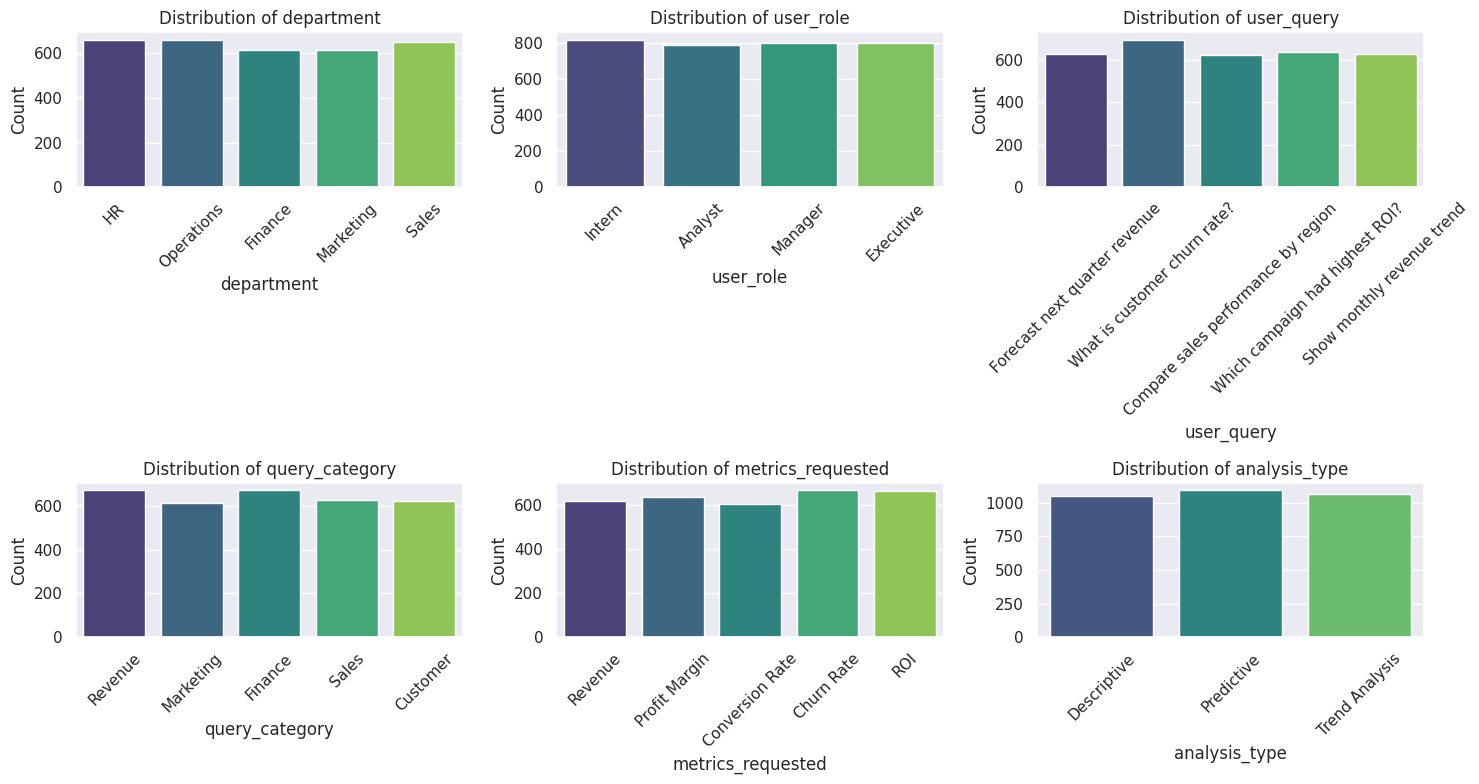

--- Categorical Value Counts ---

Value counts for department:
department
HR            660
Operations    658
Sales         650
Finance       616
Marketing     616
Name: count, dtype: int64

Value counts for user_role:
user_role
Intern       817
Executive    798
Manager      796
Analyst      789
Name: count, dtype: int64

Value counts for user_query:
user_query
What is customer churn rate?           693
Which campaign had highest ROI?        637
Show monthly revenue trend             626
Forecast next quarter revenue          624
Compare sales performance by region    620
Name: count, dtype: int64

Value counts for query_category:
query_category
Finance      671
Revenue      670
Sales        626
Customer     621
Marketing    612
Name: count, dtype: int64

Value counts for metrics_requested:
metrics_requested
Churn Rate         670
ROI                666
Profit Margin      640
Revenue            619
Conversion Rate    605
Name: count, dtype: int64

Value counts for analysis_type:
analys

In [ ]:
import math

# --- 1. Numerical Columns (Histograms in a Grid) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

if len(numerical_cols) > 0:
    # Defining grid size
    num_plots = len(numerical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterating and plot
    for i, col in enumerate(numerical_cols):
        sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='teal') # Added color
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

    # Hiding any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found.")


# --- 2. Categorical Columns (Countplots in a Grid) ---
# Filtering out columns with too many unique values (like IDs) to avoid messy plots
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 20]

if len(categorical_cols) > 0:
    # Defining grid size
    num_plots = len(categorical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterating and plot
    for i, col in enumerate(categorical_cols):
        sns.countplot(data=df, x=col, ax=axes[i], palette='viridis', hue=col, legend=False) # Added palette
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
        axes[i].tick_params(axis='x', rotation=45)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

     # --- 3. Value Counts (Text Output) ---
    print("--- Categorical Value Counts ---")
    for col in categorical_cols:
        print(f"\nValue counts for {col}:")
        print(df[col].value_counts())
else:
    print("No categorical columns found (or all have high cardinality).")

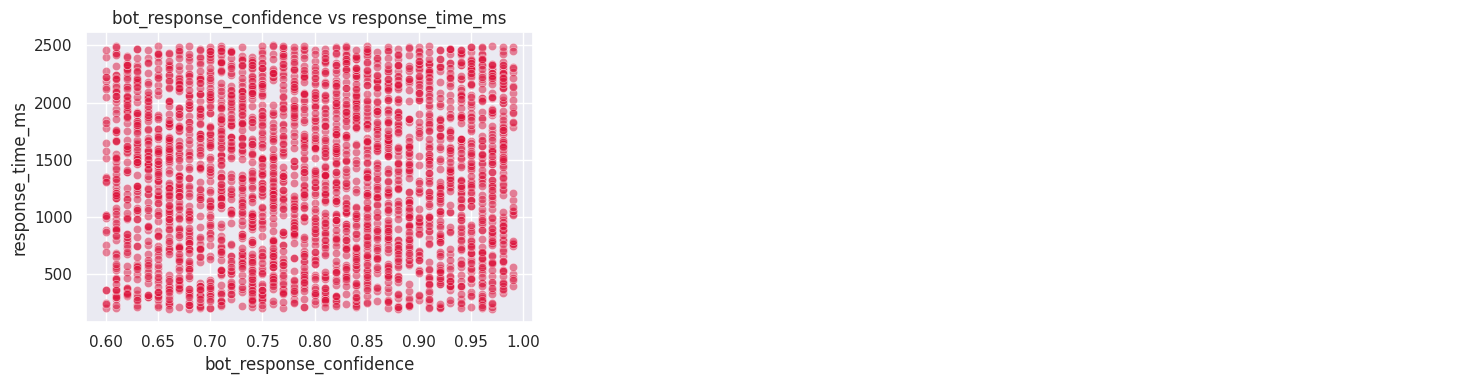

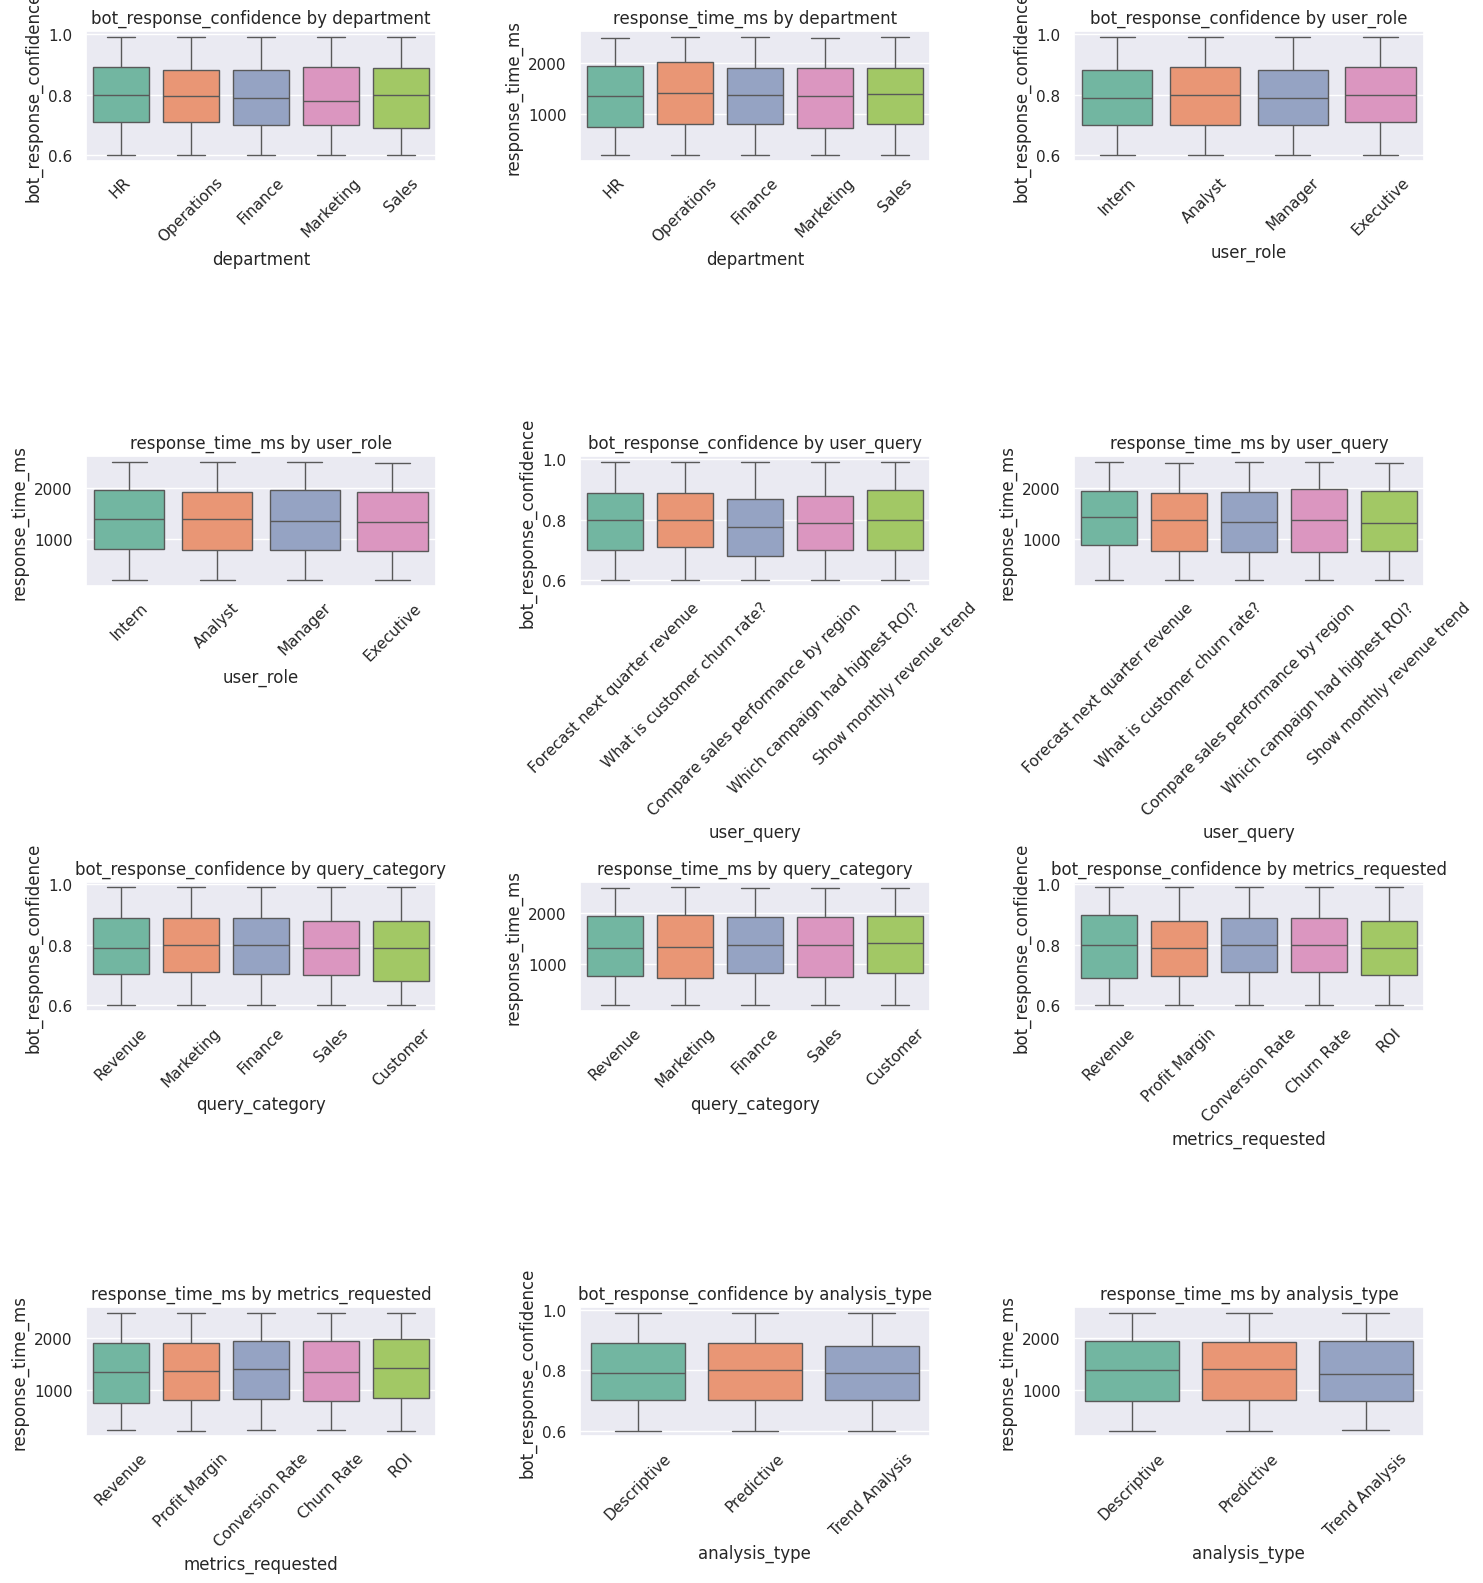

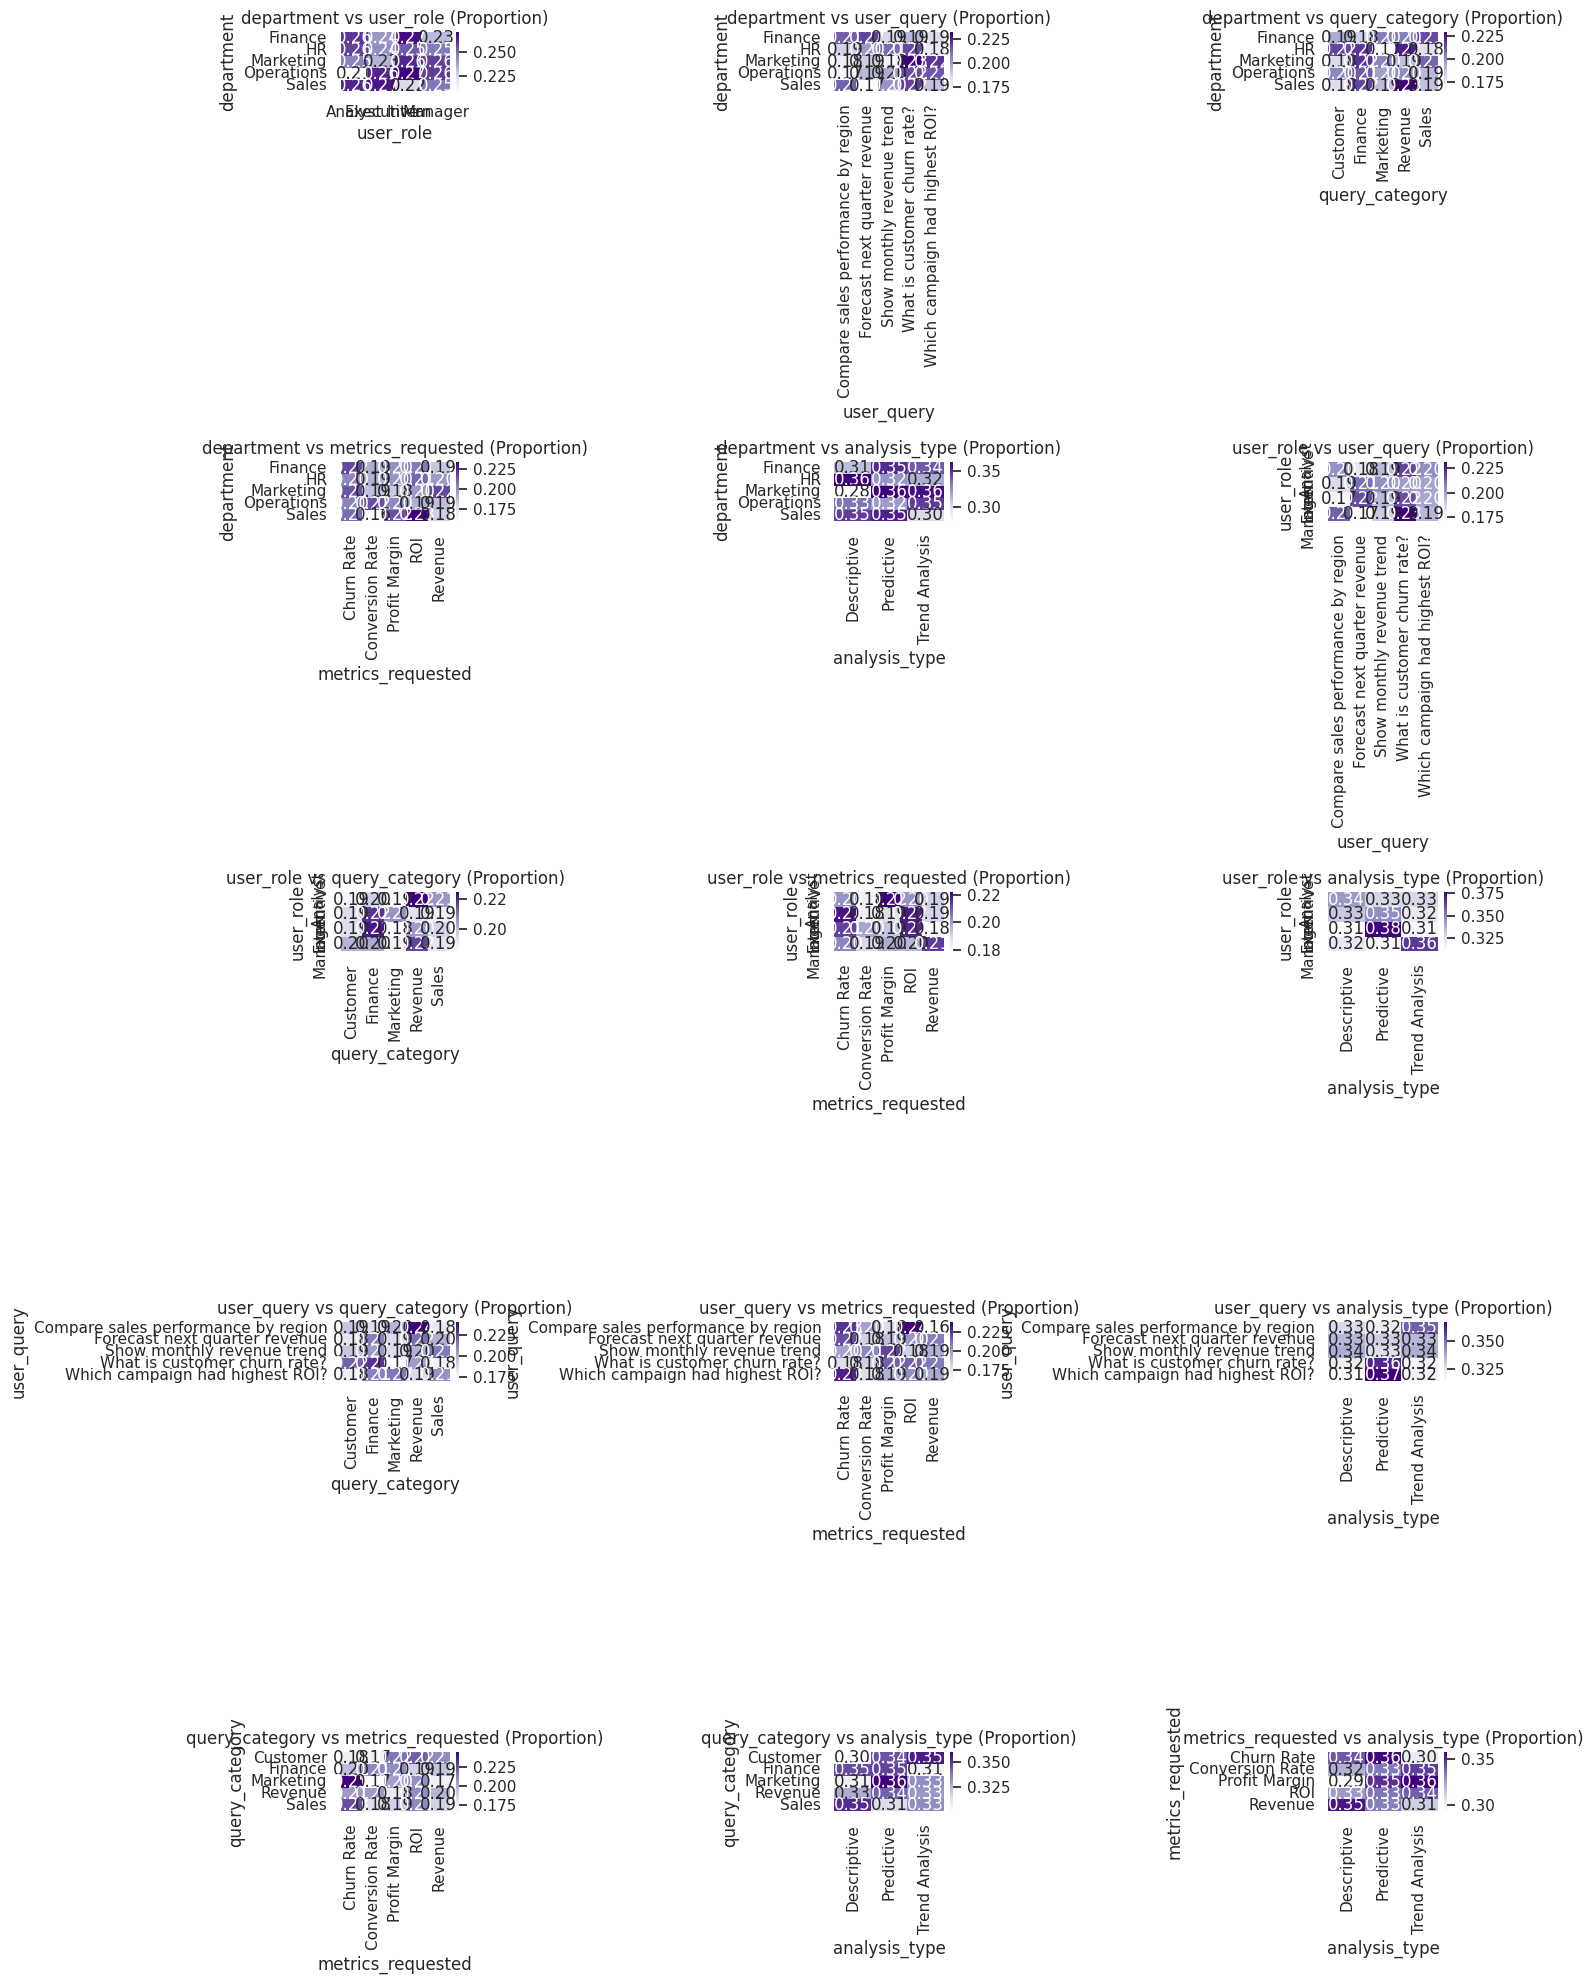

In [ ]:
import itertools

# --- 1. Numerical-Numerical Relationships (Scatter Plots) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generating all unique pairs of numerical columns
num_pairs = list(itertools.combinations(numerical_cols, 2))

if len(num_pairs) > 0:
    # Defining grid size
    num_plots = len(num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    # Ensure axes is always a flat iterable of Axes objects
    if not isinstance(axes, np.ndarray):
        axes = [axes]
    else:
        axes = axes.flatten()

    # Iterating through pairs and plot
    for i, (col1, col2) in enumerate(num_pairs):
        sns.scatterplot(data=df, x=col1, y=col2, ax=axes[i], alpha=0.5, color='crimson') # Added color
        axes[i].set_title(f'{col1} vs {col2}')
        axes[i].set_xlabel(col1)
        axes[i].set_ylabel(col2)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Not enough numerical columns for scatter plots.")


# --- 2. Categorical-Numerical Relationships (Box Plots) ---
# Excluding high cardinality columns
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 20]
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generating all pairs of (Categorical, Numerical)
cat_num_pairs = list(itertools.product(categorical_cols, numerical_cols))

if len(cat_num_pairs) > 0:
    # Defining grid size
    num_plots = len(cat_num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    # Ensure axes is always a flat iterable of Axes objects
    if not isinstance(axes, np.ndarray):
        axes = [axes]
    else:
        axes = axes.flatten()

    # Iterating through pairs and plot
    for i, (cat_col, num_col) in enumerate(cat_num_pairs):
        sns.boxplot(data=df, x=cat_col, y=num_col, ax=axes[i], palette='Set2', hue=cat_col, legend=False)
        axes[i].set_title(f'{num_col} by {cat_col}')
        axes[i].set_xlabel(cat_col)
        axes[i].set_ylabel(num_col)
        axes[i].tick_params(axis='x', rotation=45)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No categorical-numerical pairs found.")


# --- 3. Categorical-Categorical Relationships (Heatmaps) ---
# Generating pairs of categorical columns
cat_pairs = list(itertools.combinations(categorical_cols, 2))

if len(cat_pairs) > 0:
    num_plots = len(cat_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    if not isinstance(axes, np.ndarray):
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, (col1, col2) in enumerate(cat_pairs):
        # Creating a cross-tabulation
        crosstab = pd.crosstab(df[col1], df[col2], normalize='index')
        sns.heatmap(crosstab, annot=True, fmt='.2f', cmap='Purples', ax=axes[i])
        axes[i].set_title(f'{col1} vs {col2} (Proportion)')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

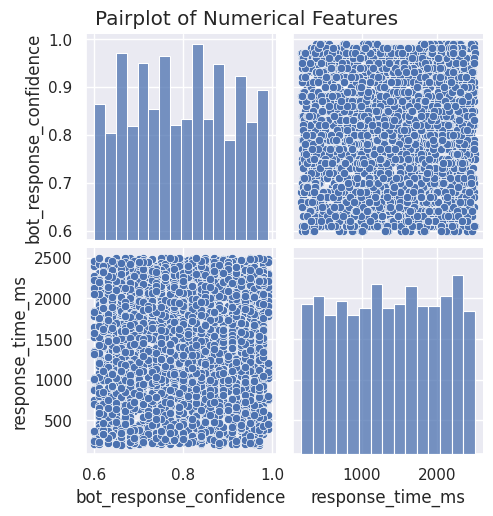

In [ ]:
sns.pairplot(df.select_dtypes(include = np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

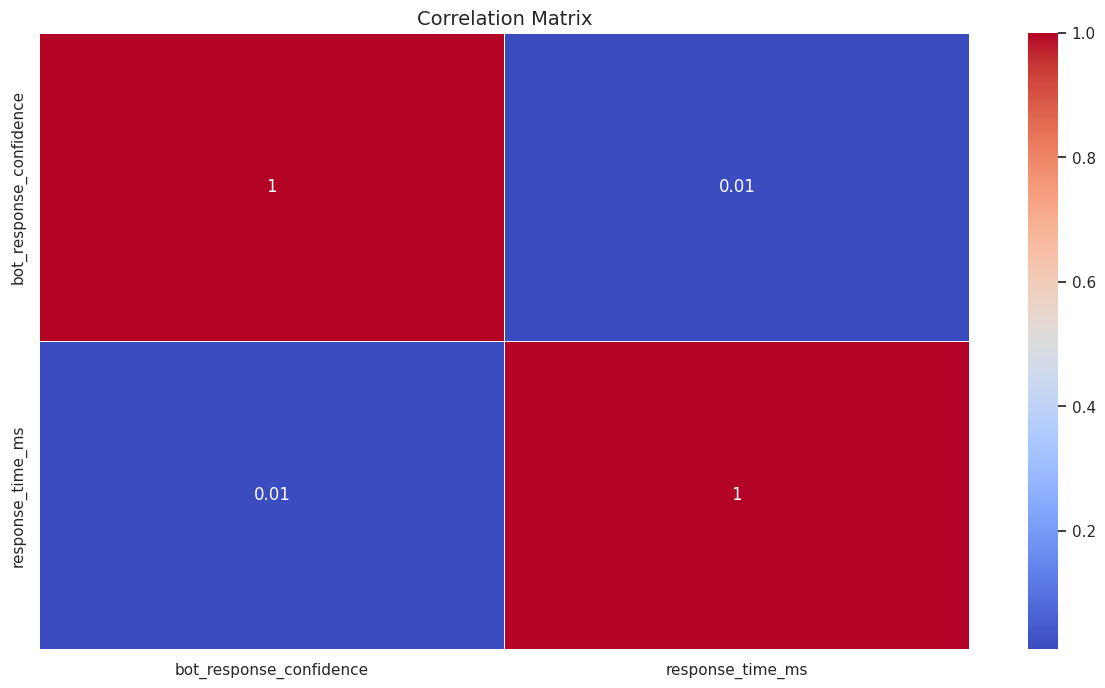

In [ ]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Statistical Analysis

### Convert Timestamp and Extract Time Features


In [ ]:

df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour_of_day'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.day_name()
df['month'] = df['timestamp'].dt.month_name()

print(df.head())
print(df.info())

  interaction_id                  timestamp  department  user_role  \
0     INT-100000 2025-08-12 08:29:31.851880          HR     Intern   
1     INT-100001 2025-10-08 15:20:31.851905  Operations    Analyst   
2     INT-100002 2025-09-21 01:42:31.851909     Finance    Manager   
3     INT-100003 2025-09-07 01:43:31.851912  Operations    Analyst   
4     INT-100004 2025-09-17 20:17:31.851914  Operations  Executive   

                            user_query query_category metrics_requested  \
0        Forecast next quarter revenue        Revenue           Revenue   
1        Forecast next quarter revenue      Marketing     Profit Margin   
2         What is customer churn rate?      Marketing   Conversion Rate   
3  Compare sales performance by region      Marketing   Conversion Rate   
4      Which campaign had highest ROI?      Marketing   Conversion Rate   

    analysis_type  bot_response_confidence  response_time_ms  hour_of_day  \
0     Descriptive                     0.73         

## Detailed Descriptive Statistics


### Detailed Descriptive Statistics for Numerical Columns

--- bot_response_confidence ---
Mean:               0.79
Median:             0.79
Mode:               0.74
Standard Deviation: 0.11
Variance:           0.01
Skewness:           0.03
Kurtosis:           -1.16
Min:                0.60
25th Percentile:    0.70
50th Percentile:    0.79
75th Percentile:    0.89
Max:                0.99


--- response_time_ms ---
Mean:               1363.89
Median:             1369.50
Mode:               1467
Standard Deviation: 664.42
Variance:           441452.21
Skewness:           -0.04
Kurtosis:           -1.20
Min:                200.00
25th Percentile:    795.00
50th Percentile:    1369.50
75th Percentile:    1941.00
Max:                2499.00


--- hour_of_day ---
Mean:               11.38
Median:             11.00
Mode:               12
Standard Deviation: 6.83
Variance:           46.68
Skewness:           0.01
Kurtosis:           -1.17
Min:                0.00
25th Percentile:    5.00
50th

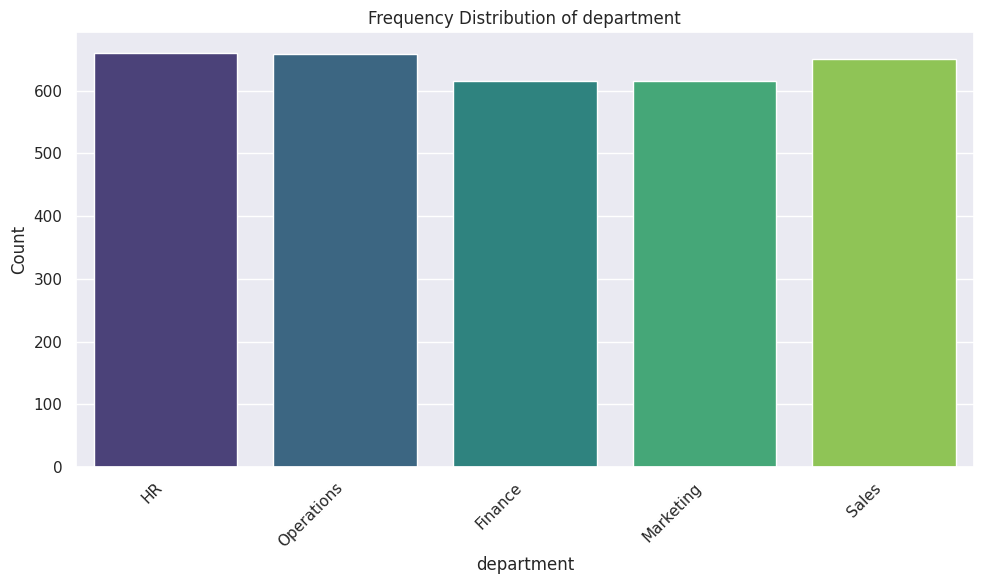



--- Frequency Distribution for user_role ---
user_role
Intern       817
Executive    798
Manager      796
Analyst      789
Name: count, dtype: int64




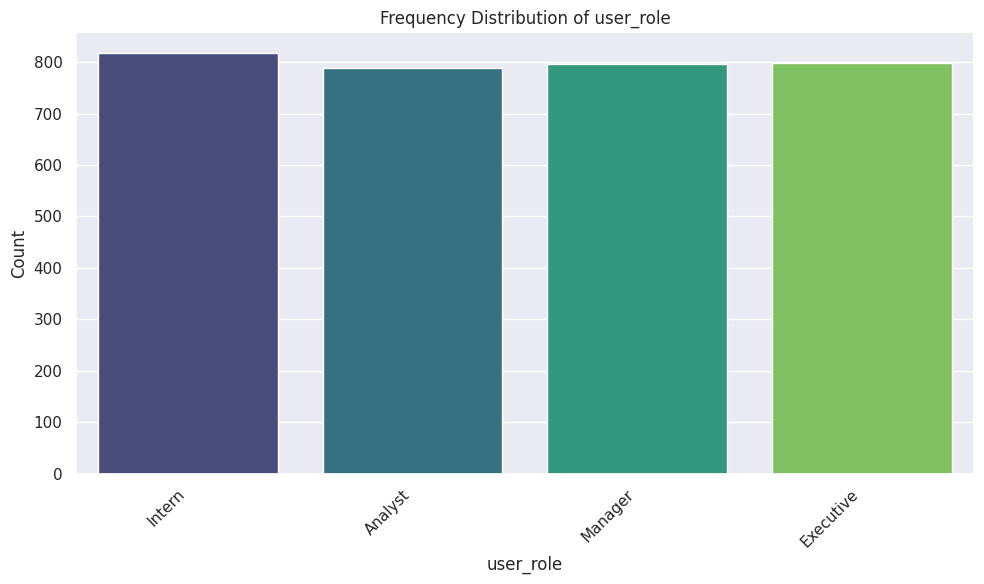



--- Frequency Distribution for user_query ---
user_query
What is customer churn rate?           693
Which campaign had highest ROI?        637
Show monthly revenue trend             626
Forecast next quarter revenue          624
Compare sales performance by region    620
Name: count, dtype: int64




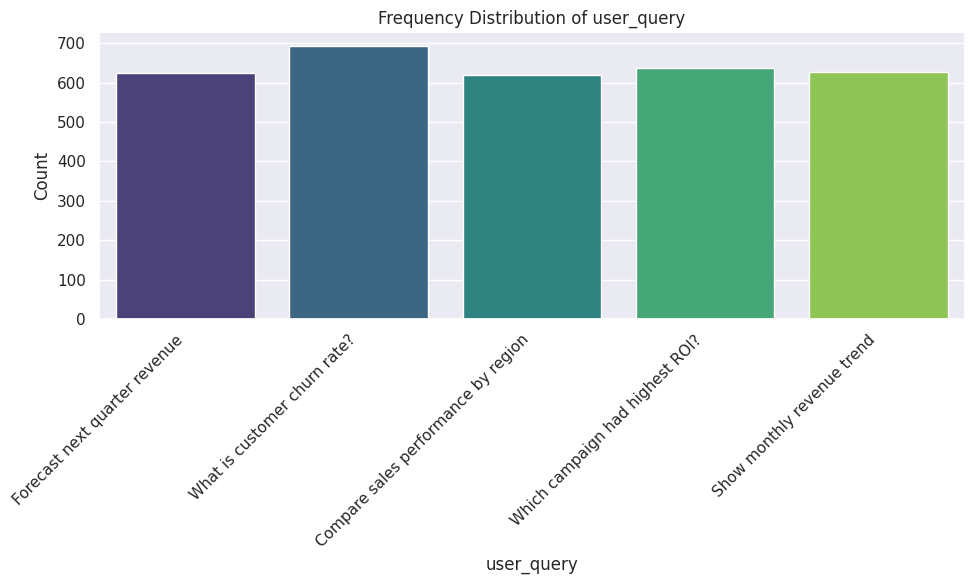



--- Frequency Distribution for query_category ---
query_category
Finance      671
Revenue      670
Sales        626
Customer     621
Marketing    612
Name: count, dtype: int64




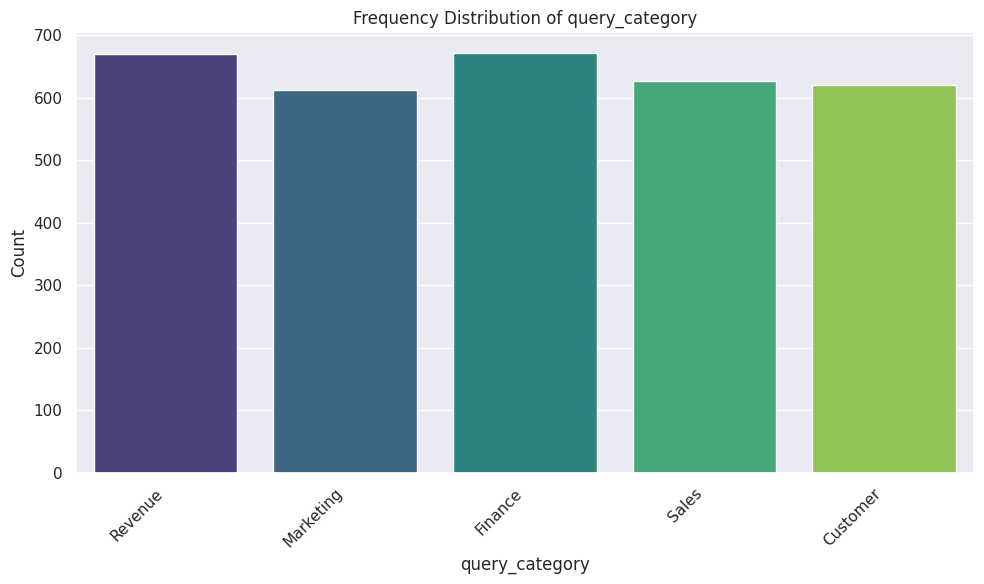



--- Frequency Distribution for metrics_requested ---
metrics_requested
Churn Rate         670
ROI                666
Profit Margin      640
Revenue            619
Conversion Rate    605
Name: count, dtype: int64




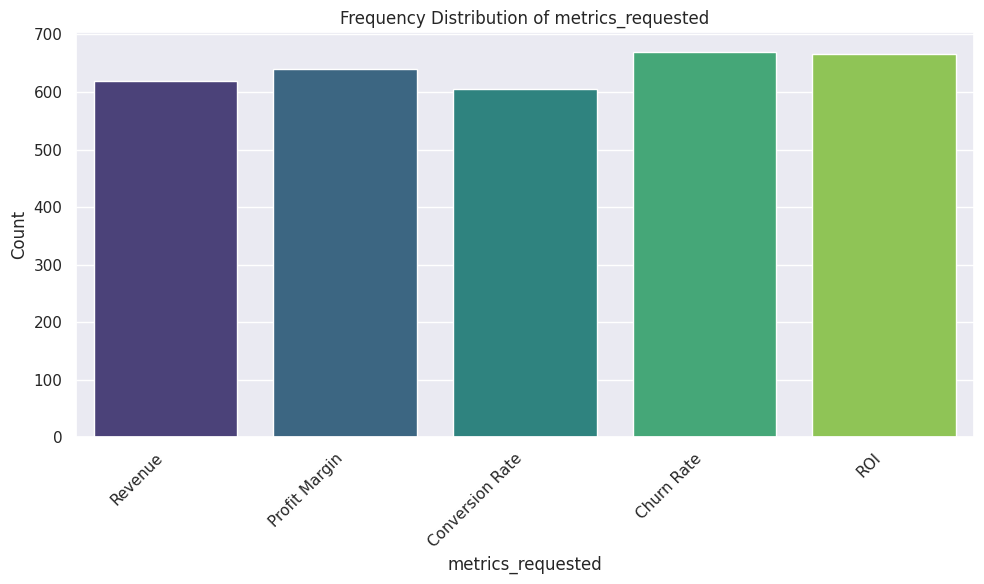



--- Frequency Distribution for analysis_type ---
analysis_type
Predictive        1093
Trend Analysis    1061
Descriptive       1046
Name: count, dtype: int64




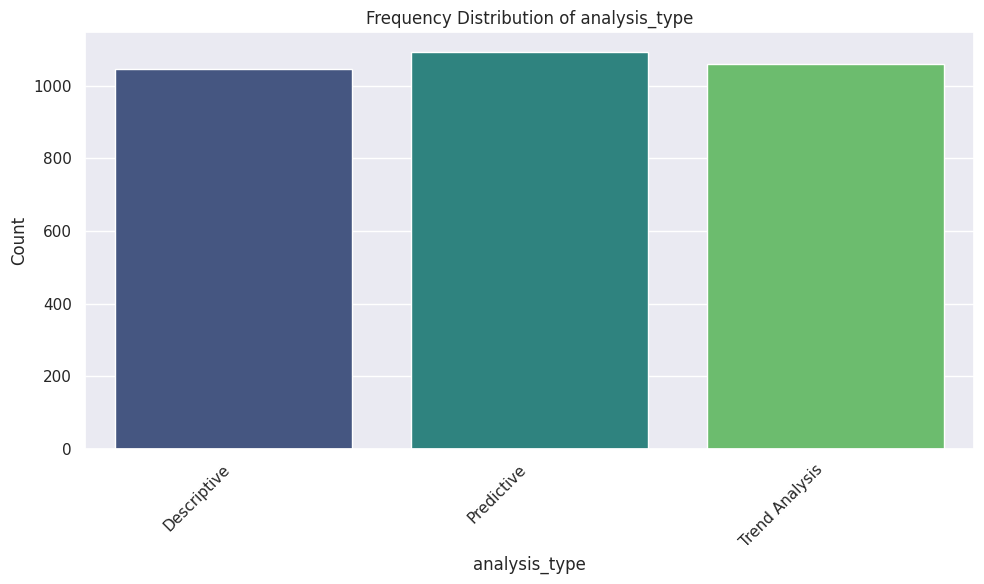

In [ ]:
# 1. Numerical Columns - Detailed Descriptive Statistics
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

if numerical_cols:
    print("### Detailed Descriptive Statistics for Numerical Columns\n")
    for col in numerical_cols:
        print(f"--- {col} ---")
        desc_stats = df[col].describe()
        mode_val = df[col].mode().iloc[0] if not df[col].mode().empty else 'N/A'
        variance_val = df[col].var()
        skewness_val = df[col].skew()
        kurtosis_val = df[col].kurt()

        print(f"Mean:               {desc_stats['mean']:.2f}")
        print(f"Median:             {df[col].median():.2f}")
        print(f"Mode:               {mode_val}")
        print(f"Standard Deviation: {desc_stats['std']:.2f}")
        print(f"Variance:           {variance_val:.2f}")
        print(f"Skewness:           {skewness_val:.2f}")
        print(f"Kurtosis:           {kurtosis_val:.2f}")
        print(f"Min:                {desc_stats['min']:.2f}")
        print(f"25th Percentile:    {desc_stats['25%']:.2f}")
        print(f"50th Percentile:    {desc_stats['50%']:.2f}")
        print(f"75th Percentile:    {desc_stats['75%']:.2f}")
        print(f"Max:                {desc_stats['max']:.2f}")
        print("\n")
else:
    print("No numerical columns found for detailed descriptive statistics.")

# 2. Categorical Columns - Frequency Distributions and Bar Plots
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Exclude 'interaction_id' as it's a unique identifier and 'timestamp' is already converted to datetime
categorical_cols = [col for col in categorical_cols if col not in ['interaction_id', 'timestamp']]

if categorical_cols:
    print("----Frequency Distributions and Bar Plots for Categorical Columns\n----")
    for col in categorical_cols:
        print(f"--- Frequency Distribution for {col} ---")
        print(df[col].value_counts())
        print("\n")

        plt.figure(figsize=(10, 6))
        sns.countplot(data=df, x=col, palette='viridis', hue=col, legend=False)
        plt.title(f'Frequency Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
        print("\n" + "="*80 + "\n")
else:
    print("No categorical columns found for frequency distributions and bar plots.")

## ANOVA for Numerical vs. Categorical



--- ANOVA for bot_response_confidence ---

Analyzing bot_response_confidence by department:
F-statistic: 0.58
P-value: 0.674


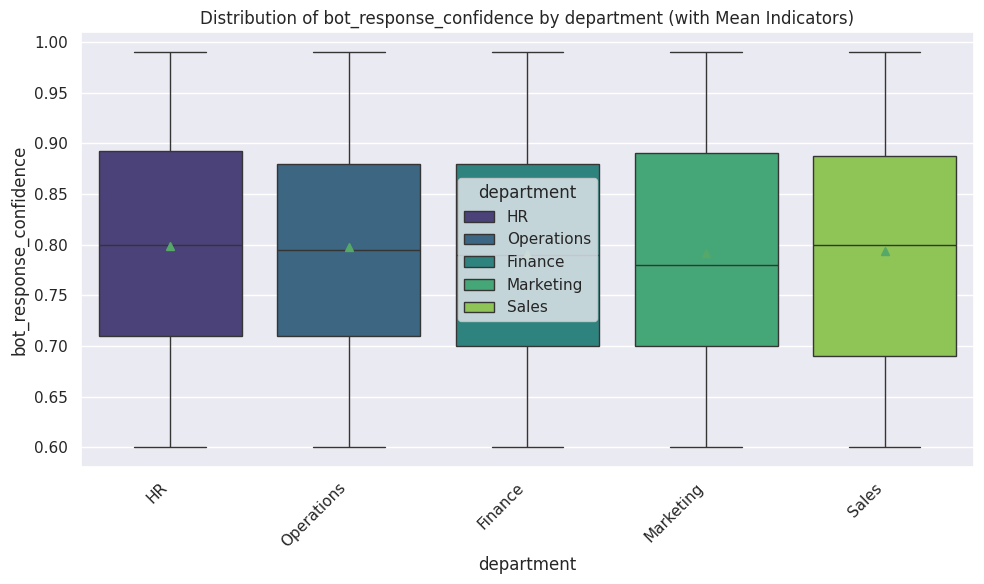


Analyzing bot_response_confidence by user_role:
F-statistic: 0.74
P-value: 0.529


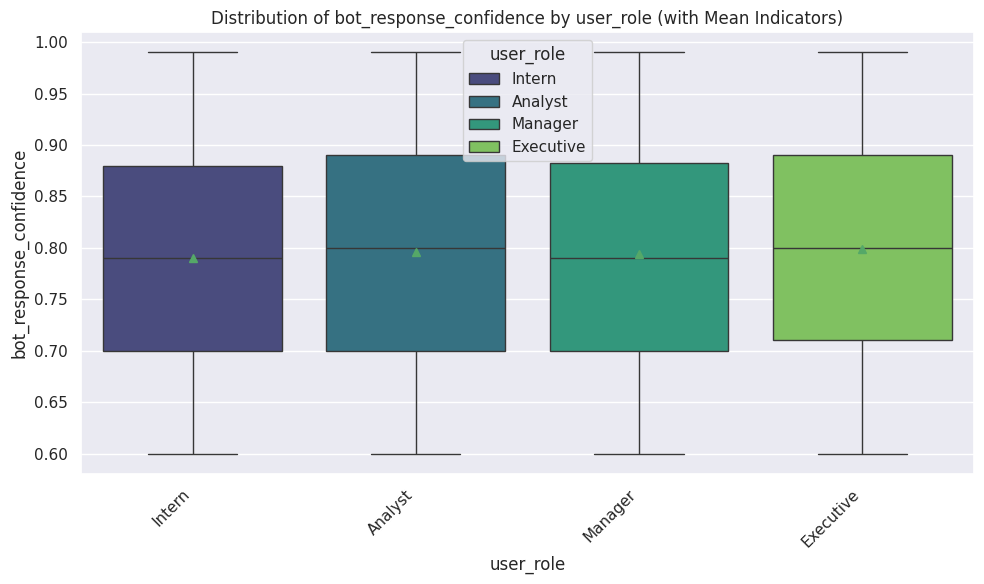


Analyzing bot_response_confidence by query_category:
F-statistic: 0.71
P-value: 0.583


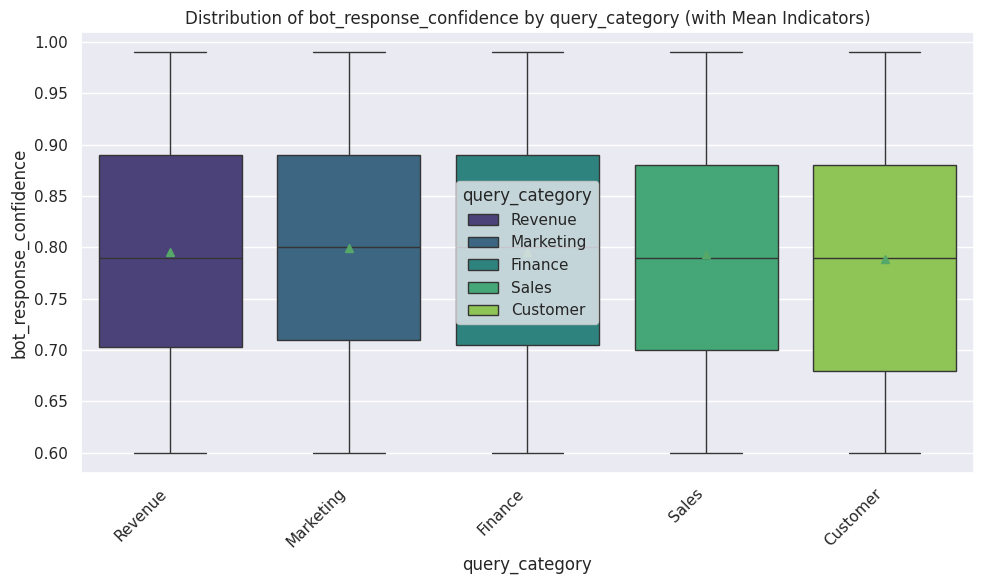


Analyzing bot_response_confidence by metrics_requested:
F-statistic: 0.96
P-value: 0.430


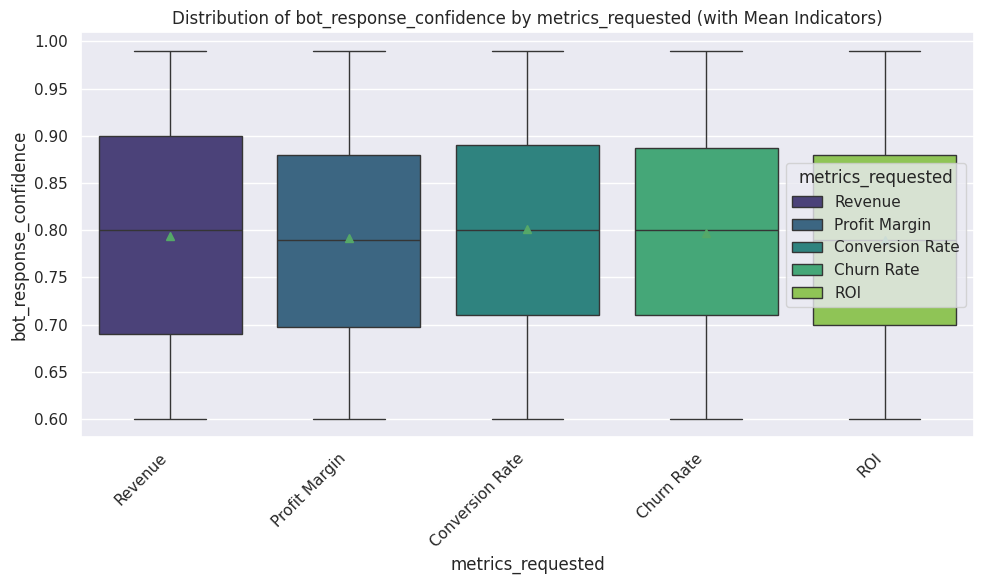


Analyzing bot_response_confidence by analysis_type:
F-statistic: 0.05
P-value: 0.947


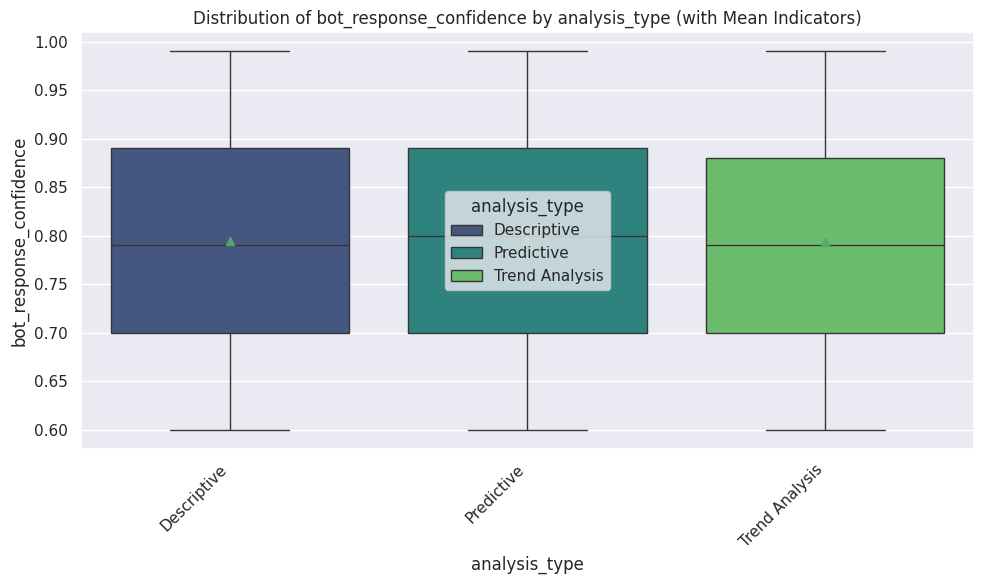


--- ANOVA for response_time_ms ---

Analyzing response_time_ms by department:
F-statistic: 1.16
P-value: 0.326


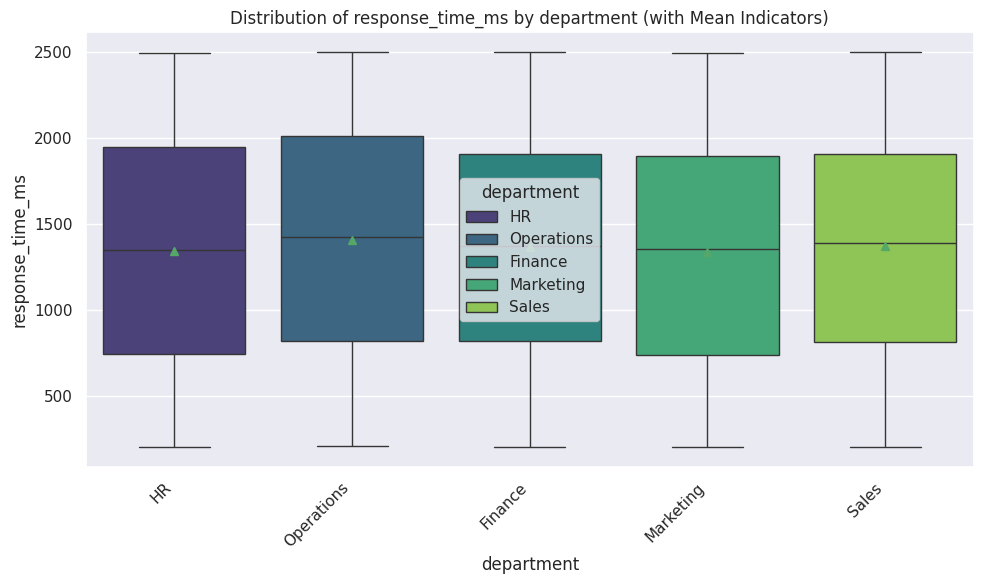


Analyzing response_time_ms by user_role:
F-statistic: 0.59
P-value: 0.620


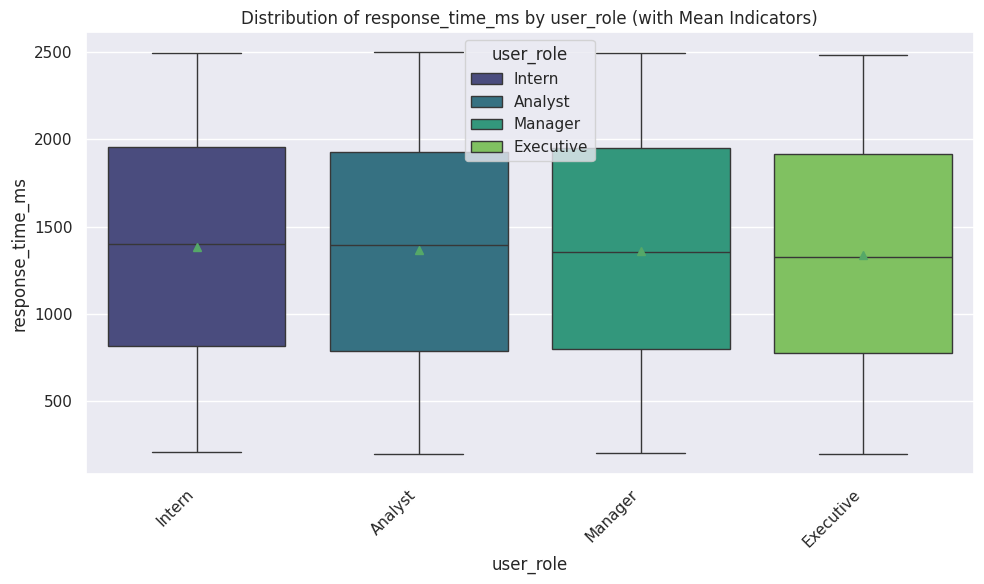


Analyzing response_time_ms by query_category:
F-statistic: 0.34
P-value: 0.852


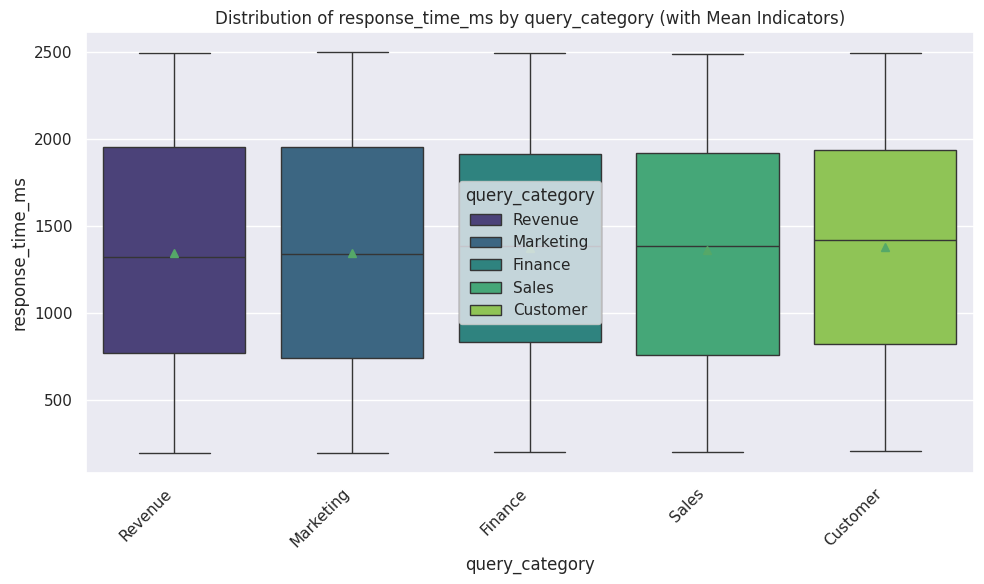


Analyzing response_time_ms by metrics_requested:
F-statistic: 0.71
P-value: 0.583


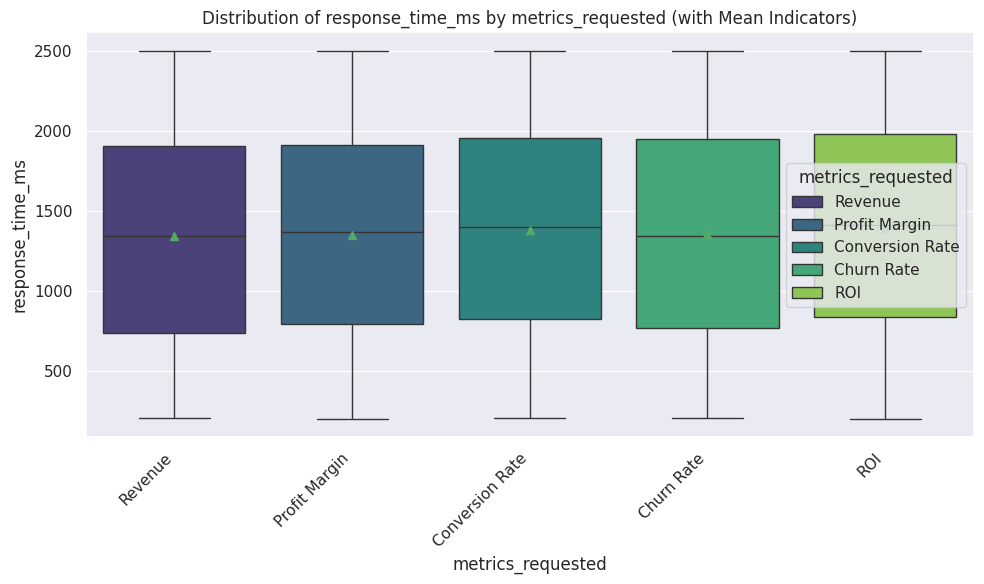


Analyzing response_time_ms by analysis_type:
F-statistic: 0.60
P-value: 0.549


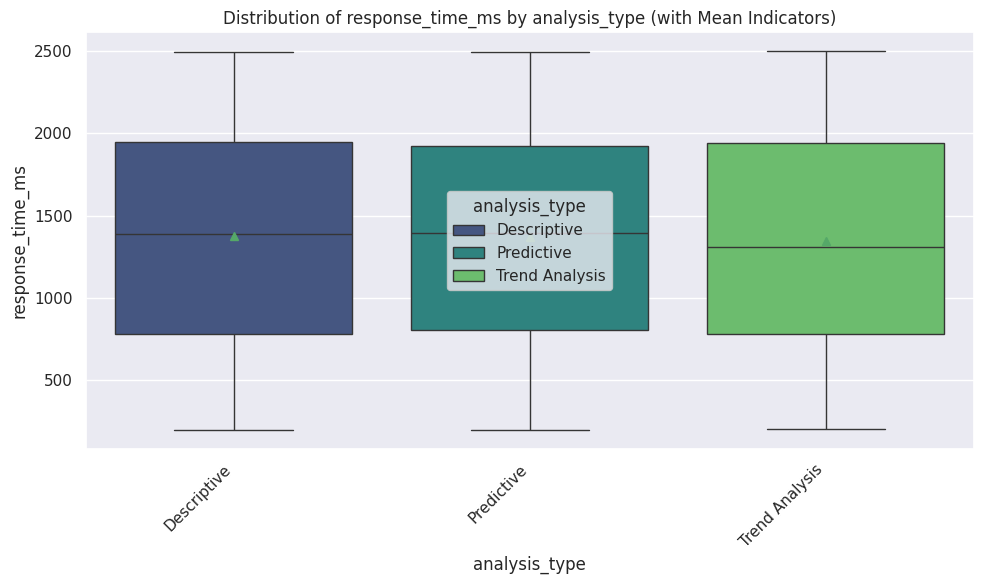

In [ ]:
from scipy.stats import f_oneway

# Define numerical and categorical columns for ANOVA
numerical_anova_cols = ['bot_response_confidence', 'response_time_ms']
categorical_anova_cols = ['department', 'user_role', 'query_category', 'metrics_requested', 'analysis_type']

# Loop through each numerical column
for num_col in numerical_anova_cols:
    print(f"\n--- ANOVA for {num_col} ---")
    # Loop through each categorical column
    for cat_col in categorical_anova_cols:
        print(f"\nAnalyzing {num_col} by {cat_col}:")

        # Prepare data for ANOVA
        groups = []
        for category in df[cat_col].unique():
            groups.append(df[df[cat_col] == category][num_col])

        # Perform ANOVA test
        f_statistic, p_value = f_oneway(*groups)
        print(f"F-statistic: {f_statistic:.2f}")
        print(f"P-value: {p_value:.3f}")

        # Create box plot
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df, x=cat_col, y=num_col, showmeans=True, hue=cat_col, legend=True, palette='viridis')
        plt.title(f'Distribution of {num_col} by {cat_col} (with Mean Indicators)')
        plt.xlabel(cat_col)
        plt.ylabel(num_col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
        print("="*80)


## Chi-Squared Tests for Categorical Associations


In [ ]:
from scipy.stats import chi2_contingency
import itertools

# Define the list of categorical columns to analyze
categorical_cols = ['department', 'user_role', 'user_query', 'query_category', 'metrics_requested', 'analysis_type', 'day_of_week', 'month']

# Iterate through all unique pairs of categorical columns
for col1, col2 in itertools.combinations(categorical_cols, 2):
    print(f"\n--- Analyzing Association Between {col1} and {col2} ---")

    # Create a contingency table
    contingency_table = pd.crosstab(df[col1], df[col2])
    print("Contingency Table:")
    print(contingency_table)

    # Perform the Chi-Squared test of independence
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    print(f"\nChi-Squared Statistic: {chi2:.2f}")
    print(f"P-value: {p_value:.3f}")

    # Interpret the p-value
    alpha = 0.05
    if p_value < alpha:
        print(f"Conclusion: Since the p-value ({p_value:.3f}) is less than the significance level ({alpha}), we reject the null hypothesis. There is a statistically significant association between {col1} and {col2}.")
    else:
        print(f"Conclusion: Since the p-value ({p_value:.3f}) is greater than the significance level ({alpha}), we fail to reject the null hypothesis. There is no statistically significant association between {col1} and {col2}.")
    print("="*80)



--- Analyzing Association Between department and user_role ---
Contingency Table:
user_role   Analyst  Executive  Intern  Manager
department                                     
Finance         160        148     165      143
HR              170        160     167      163
Marketing       151        144     162      159
Operations      137        173     178      170
Sales           171        173     145      161

Chi-Squared Statistic: 12.49
P-value: 0.407
Conclusion: Since the p-value (0.407) is greater than the significance level (0.05), we fail to reject the null hypothesis. There is no statistically significant association between department and user_role.

--- Analyzing Association Between department and user_query ---
Contingency Table:
user_query  Compare sales performance by region  \
department                                        
Finance                                     132   
HR                                          124   
Marketing                               

## Time-based Trend Analysis

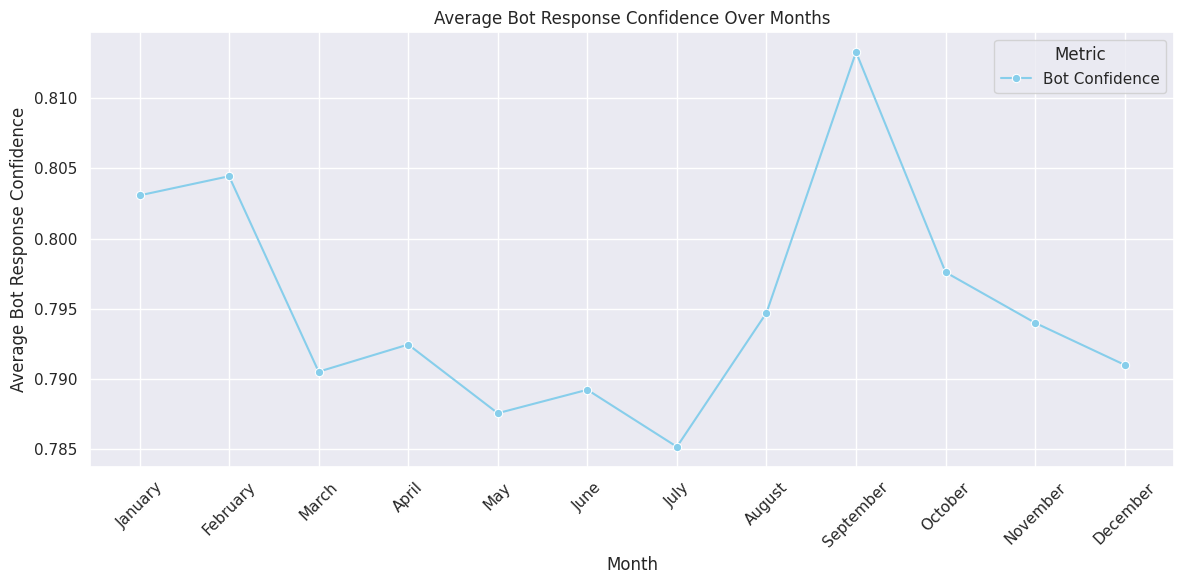

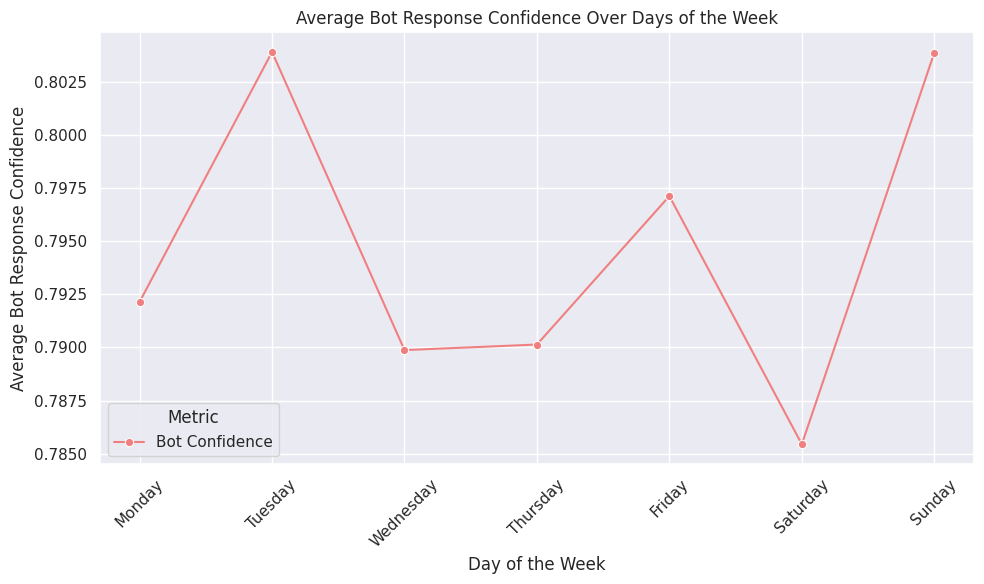

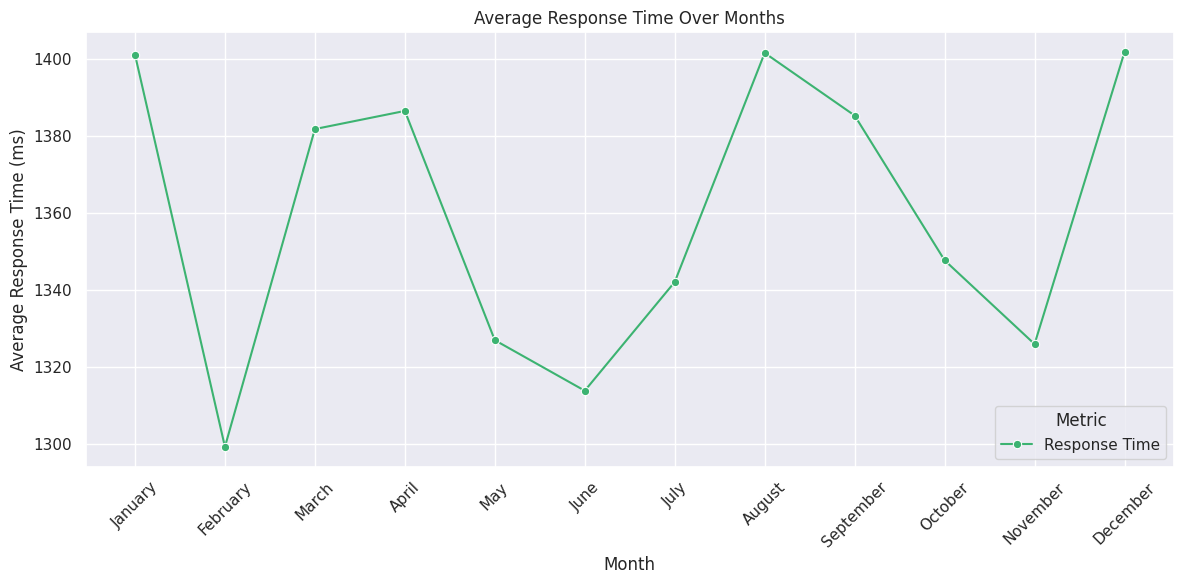

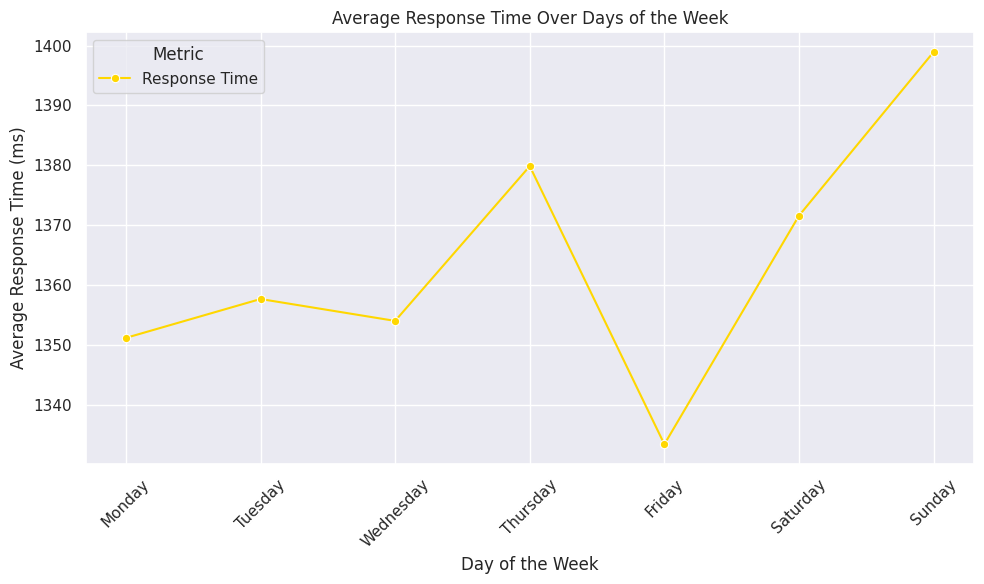

In [ ]:

# Defining the order for months and days of the week
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Converting 'month' and 'day_of_week' to categorical types with defined order
df['month'] = pd.Categorical(df['month'], categories=month_order, ordered=True)
df['day_of_week'] = pd.Categorical(df['day_of_week'], categories=day_order, ordered=True)

# 1. Mean bot_response_confidence per month
monthly_confidence = df.groupby('month')['bot_response_confidence'].mean().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_confidence, x='month', y='bot_response_confidence', marker='o', color='skyblue')
plt.title('Average Bot Response Confidence Over Months')
plt.xlabel('Month')
plt.ylabel('Average Bot Response Confidence')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title='Metric', labels=['Bot Confidence'])
plt.tight_layout()
plt.show()

# 2. Mean bot_response_confidence per day of the week
daily_confidence = df.groupby('day_of_week')['bot_response_confidence'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.lineplot(data=daily_confidence, x='day_of_week', y='bot_response_confidence', marker='o', color='lightcoral')
plt.title('Average Bot Response Confidence Over Days of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Average Bot Response Confidence')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title='Metric', labels=['Bot Confidence'])
plt.tight_layout()
plt.show()

# 3. Mean response_time_ms per month
monthly_response_time = df.groupby('month')['response_time_ms'].mean().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_response_time, x='month', y='response_time_ms', marker='o', color='mediumseagreen')
plt.title('Average Response Time Over Months')
plt.xlabel('Month')
plt.ylabel('Average Response Time (ms)')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title='Metric', labels=['Response Time'])
plt.tight_layout()
plt.show()

# 4. Mean response_time_ms per day of the week
daily_response_time = df.groupby('day_of_week')['response_time_ms'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.lineplot(data=daily_response_time, x='day_of_week', y='response_time_ms', marker='o', color='gold')
plt.title('Average Response Time Over Days of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Average Response Time (ms)')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title='Metric', labels=['Response Time'])
plt.tight_layout()
plt.show()

# Feature Engineering | NLP & Metadata

In [ ]:
import re
from textblob import TextBlob

print("--- 1. TEXT CLEANING & METRICS ---")
# Identifying the text column (adjust 'user_query' to your actual column name)
text_col = [c for c in df.columns if 'query' in c.lower() or 'text' in c.lower() or 'message' in c.lower()][0]
print(f"Engineering features from: {text_col}")

# A. Cleaninging Function (Remove noise)
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

df['Clean_Text'] = df[text_col].apply(clean_text)

# B. Complexity Features (Length = Complexity?)
df['Word_Count'] = df[text_col].apply(lambda x: len(str(x).split()))
df['Char_Count'] = df[text_col].apply(len)

print("✅ Created: Clean_Text, Word_Count, Char_Count")


print("\n--- 2. SENTIMENT & EMOTION FEATURES ---")
# Using TextBlob to extract "Mood" and "Opinion"

def get_sentiment_features(text):
    blob = TextBlob(str(text))
    return pd.Series([blob.sentiment.polarity, blob.sentiment.subjectivity])

df[['Sentiment_Polarity', 'Sentiment_Subjectivity']] = df[text_col].apply(get_sentiment_features)

# Creating a "Frustration Flag" (Negative sentiment + High Subjectivity)
df['Is_Frustrated'] = ((df['Sentiment_Polarity'] < -0.1) & (df['Sentiment_Subjectivity'] > 0.5)).astype(int)

print("✅ Created: Sentiment_Polarity, Sentiment_Subjectivity, Is_Frustrated")


print("\n--- 3. TEMPORAL PATTERNS (TIME FEATURES) ---")

# When do people chat? (Late night = Urgent?)
time_col = [c for c in df.columns if 'time' in c.lower() or 'date' in c.lower()][0]

if time_col:
    df[time_col] = pd.to_datetime(df[time_col])

    df['Hour_of_Day'] = df[time_col].dt.hour
    df['Day_of_Week'] = df[time_col].dt.dayofweek
    df['Is_Weekend'] = df['Day_of_Week'].apply(lambda x: 1 if x >= 5 else 0)

    # "Business Hours" Flag (9 AM - 5 PM)
    df['Is_Business_Hours'] = df['Hour_of_Day'].apply(lambda x: 1 if 9 <= x <= 17 else 0)

    print("✅ Created: Hour_of_Day, Is_Weekend, Is_Business_Hours")


print("\n--- 4. KEYWORD EXTRACTION (BINARY FEATURES) ---")
# Does the user mention specific urgent words?
keywords = ['error', 'fail', 'urgent', 'bug', 'crash', 'help']

for word in keywords:
    df[f'Has_{word}'] = df['Clean_Text'].apply(lambda x: 1 if word in x else 0)

print(f"✅ Created Binary Features for: {keywords}")

# Final Preview
features_to_show = ['Clean_Text', 'Word_Count', 'Sentiment_Polarity', 'Is_Frustrated', 'Hour_of_Day']
print("\nFinal Feature Set Head:")
print(df[features_to_show].head())

--- 1. TEXT CLEANING & METRICS ---
Engineering features from: user_query
✅ Created: Clean_Text, Word_Count, Char_Count

--- 2. SENTIMENT & EMOTION FEATURES ---
✅ Created: Sentiment_Polarity, Sentiment_Subjectivity, Is_Frustrated

--- 3. TEMPORAL PATTERNS (TIME FEATURES) ---
✅ Created: Hour_of_Day, Is_Weekend, Is_Business_Hours

--- 4. KEYWORD EXTRACTION (BINARY FEATURES) ---
✅ Created Binary Features for: ['error', 'fail', 'urgent', 'bug', 'crash', 'help']

Final Feature Set Head:
                            Clean_Text  Word_Count  Sentiment_Polarity  \
0        forecast next quarter revenue           4                 0.0   
1        forecast next quarter revenue           4                 0.0   
2          what is customer churn rate           5                 0.0   
3  compare sales performance by region           5                 0.0   
4       which campaign had highest roi           5                 0.0   

   Is_Frustrated  Hour_of_Day  
0              0            8  
1    

--- 1. ANALYZING USER SENTIMENT ---
Analyzing Sentiment for: user_query

Sentiment Distribution:
Sentiment_Category
Neutral    3200
Name: count, dtype: int64


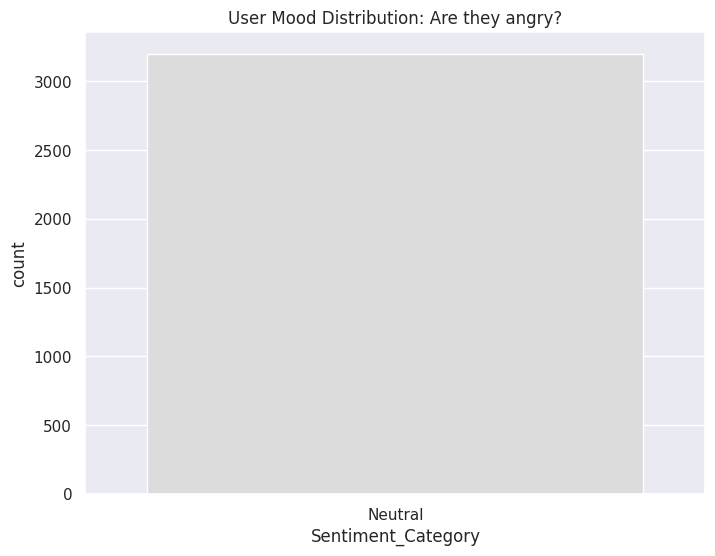


--- 2. DOES MOOD AFFECT RESOLUTION? ---


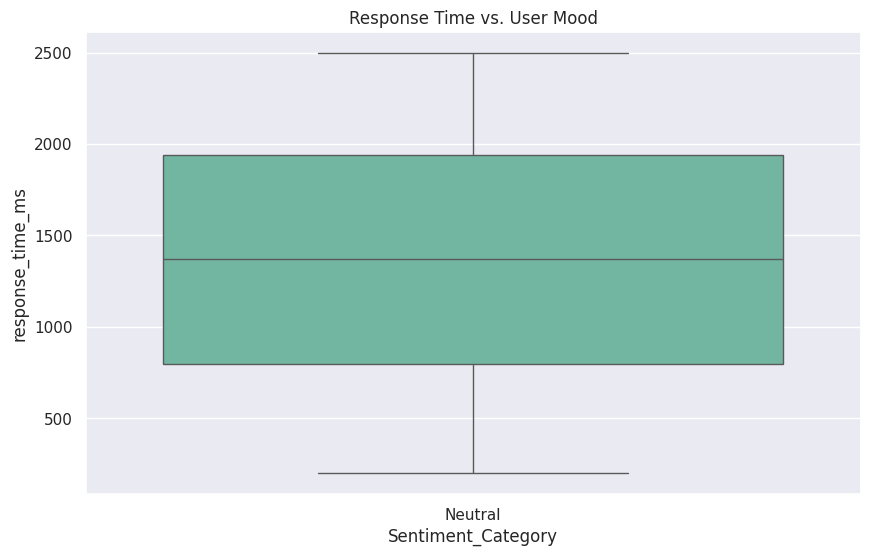

📝 INSIGHT: If 'Negative' sentiment has higher response time, we have a problem.


In [ ]:
# ==========================================
# PHASE 2: NLP & SENTIMENT ANALYSIS
# ==========================================
from textblob import TextBlob
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("--- 1. ANALYZING USER SENTIMENT ---")
# We want to know if users are Happy or Angry based on their text.
# Identify the text column (e.g., 'User_Query', 'Message', 'Text')
text_col = [c for c in df.columns if 'query' in c.lower() or 'text' in c.lower() or 'message' in c.lower()][0]
print(f"Analyzing Sentiment for: {text_col}")

# Define a function to get sentiment polarity (-1 = Negative, +1 = Positive)
def get_sentiment(text):
    return TextBlob(str(text)).sentiment.polarity

# Apply it
df['Sentiment_Score'] = df[text_col].apply(get_sentiment)

# Categorize Sentiment
def categorize_sentiment(score):
    if score > 0.1: return 'Positive'
    elif score < -0.1: return 'Negative'
    else: return 'Neutral'

df['Sentiment_Category'] = df['Sentiment_Score'].apply(categorize_sentiment)

print("\nSentiment Distribution:")
print(df['Sentiment_Category'].value_counts())

# Visualize
plt.figure(figsize=(8, 6))
sns.countplot(x='Sentiment_Category', data=df, palette='coolwarm')
plt.title('User Mood Distribution: Are they angry?')
plt.show()


print("\n--- 2. DOES MOOD AFFECT RESOLUTION? ---")
# Do angry users get slower responses? Or faster?
# Identify relevant columns (e.g., 'Response_Time', 'Resolution_Status')
time_col = [c for c in df.columns if 'time' in c.lower() and 'response' in c.lower()]

if time_col:
    time_col = time_col[0]
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Sentiment_Category', y=time_col, data=df, palette='Set2')
    plt.title('Response Time vs. User Mood')
    plt.show()
    print("📝 INSIGHT: If 'Negative' sentiment has higher response time, we have a problem.")

# Machine Learning

--- 1. PREPARING THE DATA ---
Target 1 (Intent): query_category
Target 2 (Time): response_time_ms

--- 2. MODEL A: THE INTENT CLASSIFIER (NLP) ---
✅ Intent Model Trained.

Classification Report (How well does it understand?):
              precision    recall  f1-score   support

    Customer       0.00      0.00      0.00       138
     Finance       0.18      0.59      0.28       113
   Marketing       0.00      0.00      0.00       116
     Revenue       0.24      0.25      0.25       137
       Sales       0.18      0.17      0.17       136

    accuracy                           0.19       640
   macro avg       0.12      0.20      0.14       640
weighted avg       0.12      0.19      0.14       640


--- 3. MODEL B: THE EFFICIENCY PREDICTOR (REGRESSION) ---
✅ Time Prediction Model Trained.

💰 Average Prediction Error: 586.29 seconds
🎯 Accuracy (R2 Score): -2.6%

--- 4. VISUALIZING INTELLIGENCE ---


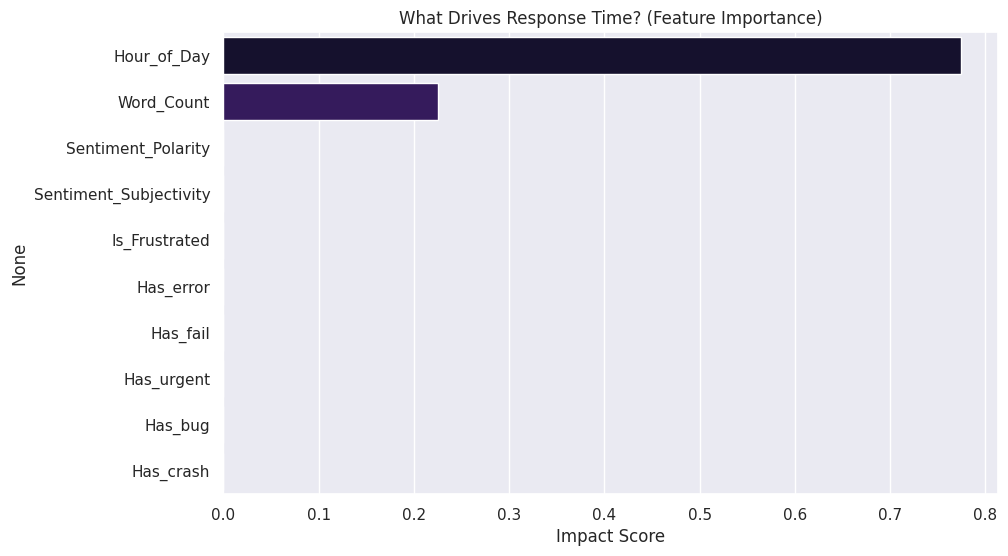

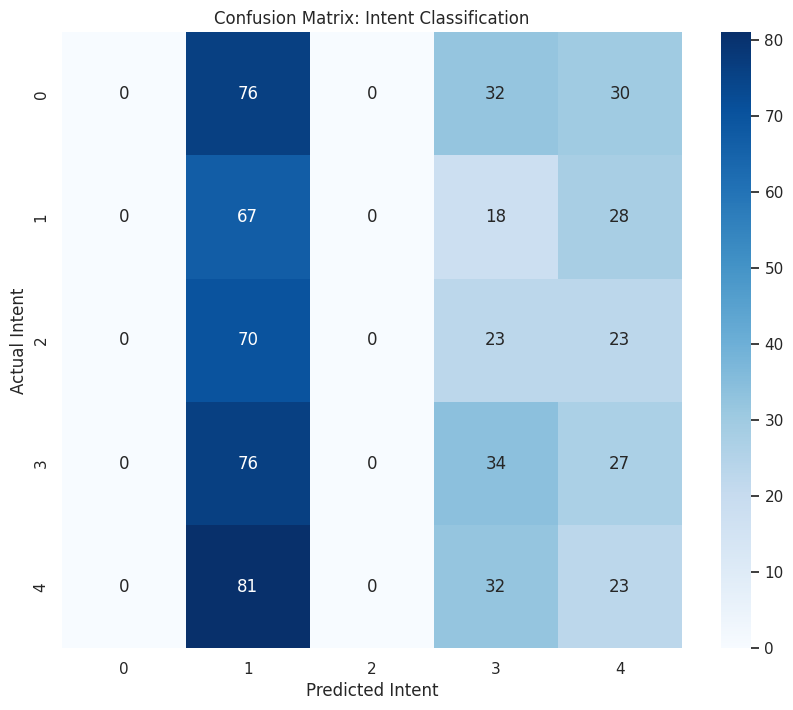

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

print("--- 1. PREPARING THE DATA ---")
# Auto-detect target columns
intent_col = [c for c in df.columns if 'intent' in c.lower() or 'category' in c.lower() or 'topic' in c.lower()][0]
time_col = [c for c in df.columns if 'response' in c.lower() and 'time' in c.lower()][0]

print(f"Target 1 (Intent): {intent_col}")
print(f"Target 2 (Time): {time_col}")

# Split Data
# We use 'Clean_Text' for the NLP model
X_text = df['Clean_Text']
y_intent = df[intent_col]
y_time = df[time_col]

# Split into Train/Test
# Note: We share the same split indices for fair comparison
X_train, X_test, y_int_train, y_int_test, y_time_train, y_time_test = train_test_split(
    X_text, y_intent, y_time, test_size=0.2, random_state=42
)


print("\n--- 2. MODEL A: THE INTENT CLASSIFIER (NLP) ---")
# This pipeline does: Raw Text -> TF-IDF (Numbers) -> Random Forest (Prediction)

intent_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=1000, stop_words='english')),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Training
intent_pipeline.fit(X_train, y_int_train)
print("✅ Intent Model Trained.")

# Evaluating
intent_preds = intent_pipeline.predict(X_test)
print("\nClassification Report (How well does it understand?):")
print(classification_report(y_int_test, intent_preds))


print("\n--- 3. MODEL B: THE EFFICIENCY PREDICTOR (REGRESSION) ---")

# This model predicts Response Time based on Complexity features we created.
# Prepareing Features (Numerical only)
feature_cols = ['Word_Count', 'Sentiment_Polarity', 'Sentiment_Subjectivity', 'Is_Frustrated', 'Hour_of_Day']

# Adding binary keyword features
feature_cols += [c for c in df.columns if c.startswith('Has_')]

X_meta_train = df.loc[X_train.index, feature_cols]
X_meta_test = df.loc[X_test.index, feature_cols]

# Training code
time_model = RandomForestRegressor(n_estimators=100, random_state=42)
time_model.fit(X_meta_train, y_time_train)
print("✅ Time Prediction Model Trained.")

# Evaluating
time_preds = time_model.predict(X_meta_test)
mae = mean_absolute_error(y_time_test, time_preds)
r2 = r2_score(y_time_test, time_preds)

print(f"\n💰 Average Prediction Error: {mae:.2f} seconds")
print(f"🎯 Accuracy (R2 Score): {r2*100:.1f}%")


print("\n--- 4. VISUALIZING INTELLIGENCE ---")
# 1. Feature Importance (What slows down the bot?)
importances = pd.Series(time_model.feature_importances_, index=feature_cols).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette='magma')
plt.title('What Drives Response Time? (Feature Importance)')
plt.xlabel('Impact Score')
plt.show()

# 2. Confusion Matrix (Where does the bot get confused?)
from sklearn.metrics import confusion_matrix
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_int_test, intent_preds), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Intent Classification')
plt.ylabel('Actual Intent')
plt.xlabel('Predicted Intent')
plt.show()

# Thank You